In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import missingno as msno 

In [2]:
df= pd.read_excel('new_data_set.xlsx')
df.head()

,pid,facilityid,examinationdate,age,sex,ee_zn_myasthener_exazerbation,zn_myasthener_krise,age_erst,age_diag,time_erst_to_diag,...,japan_classification,ee_postinterventionstatus_rb,eomg_lomg_45,eomg_lomg_50,thymom,adl_pass,qmg_pass,qol_pass,ee_auswahlbildungsabschluss_rb,schwerbehinderung
0,00QM6V52,2019009,2023-01-31 00:00:00,34.961111,0,0.0,1,17.583333,17.750000,0.166667,...,1.0,5.0,0.0,0.0,0.0,1.0,1.0,NaN,1.0,2.0
1,06U8DLMD,2019006,2023-01-31 00:00:00,59.711111,1,0.0,0,55.750000,58.916667,3.166667,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,1.0,0.0
2,0D31R9UX,2019010,2023-07-19 00:00:00,83.344444,1,1.0,0,80.666667,80.916667,0.250000,...,4.0,7.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0
3,0DAJN5Y2,2019019,2023-01-17 00:00:00,56.505556,1,0.0,0,56.166667,56.250000,0.083333,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,0.0,0.0
4,0G1WYG21,2019004,2020-12-10 00:00:00,39.986111,0,NaN,0,21.083333,21.083333,0.000000,...,4.0,2.0,0.0,0.0,0.0,1.0,NaN,0.0,2.0,0.0


In [3]:
rename_cols = {
    'facilityid': 'facilityid',
    'age': 'age',
    'sex': 'sex',
    'time_erst_to_diag': 'first_time_diagnosis',
    'mgfaklassifikation_schlimmste_historisch': 'mgfa_worst_history',
    'dekrement_testergebnis': 'decrement_test_result',
    'ee_autoimmunerkrankungen_rbzu': 'autoimmune_diseases',
    'ee_thymektomie_gr': 'thymectomy_status',
    'kortison_aktuell': 'cortisone_current',
    'azathioprin_aktuell': 'azathioprine_current',
    'mycophenolatmofetil_aktuell': 'mycophenolate_current',
    'methotrexatfolsauure_aktuell': 'methotrexate_folicacid_current',
    'rituximab_aktuell': 'rituximab_current',
    'scoreqmg_neu': 'qmg_score',
    'chronicfatigue_neu': 'chronicfatigue_score',
    'scoreqol_neu': 'qol_score',
    'scoreadl_neu': 'adl_score',
    'aktueller_mgfa_score': 'mgfa_score',
    'seronegative': 'seronegative'
}
df_original = df[list(rename_cols.keys())].rename(columns=rename_cols)
df_original.head()

,facilityid,age,sex,first_time_diagnosis,mgfa_worst_history,decrement_test_result,autoimmune_diseases,thymectomy_status,cortisone_current,azathioprine_current,mycophenolate_current,methotrexate_folicacid_current,rituximab_current,qmg_score,chronicfatigue_score,qol_score,adl_score,mgfa_score,seronegative
0,2019009,34.961111,0,0.166667,8.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0,NaN,NaN,2.0,3.0,0.0
1,2019006,59.711111,1,3.166667,2.0,1.0,NaN,0.0,0.0,0.0,1.0,0.0,0,1.0,NaN,NaN,NaN,2.0,0.0
2,2019010,83.344444,1,0.250000,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,5.0,12.0,7.0,3.0,2.0,0.0
3,2019019,56.505556,1,0.083333,2.0,NaN,NaN,0.0,1.0,1.0,0.0,0.0,0,4.0,8.0,NaN,NaN,2.0,0.0
4,2019004,39.986111,0,0.000000,5.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,0,NaN,NaN,10.0,1.0,3.0,0.0


<Axes: >

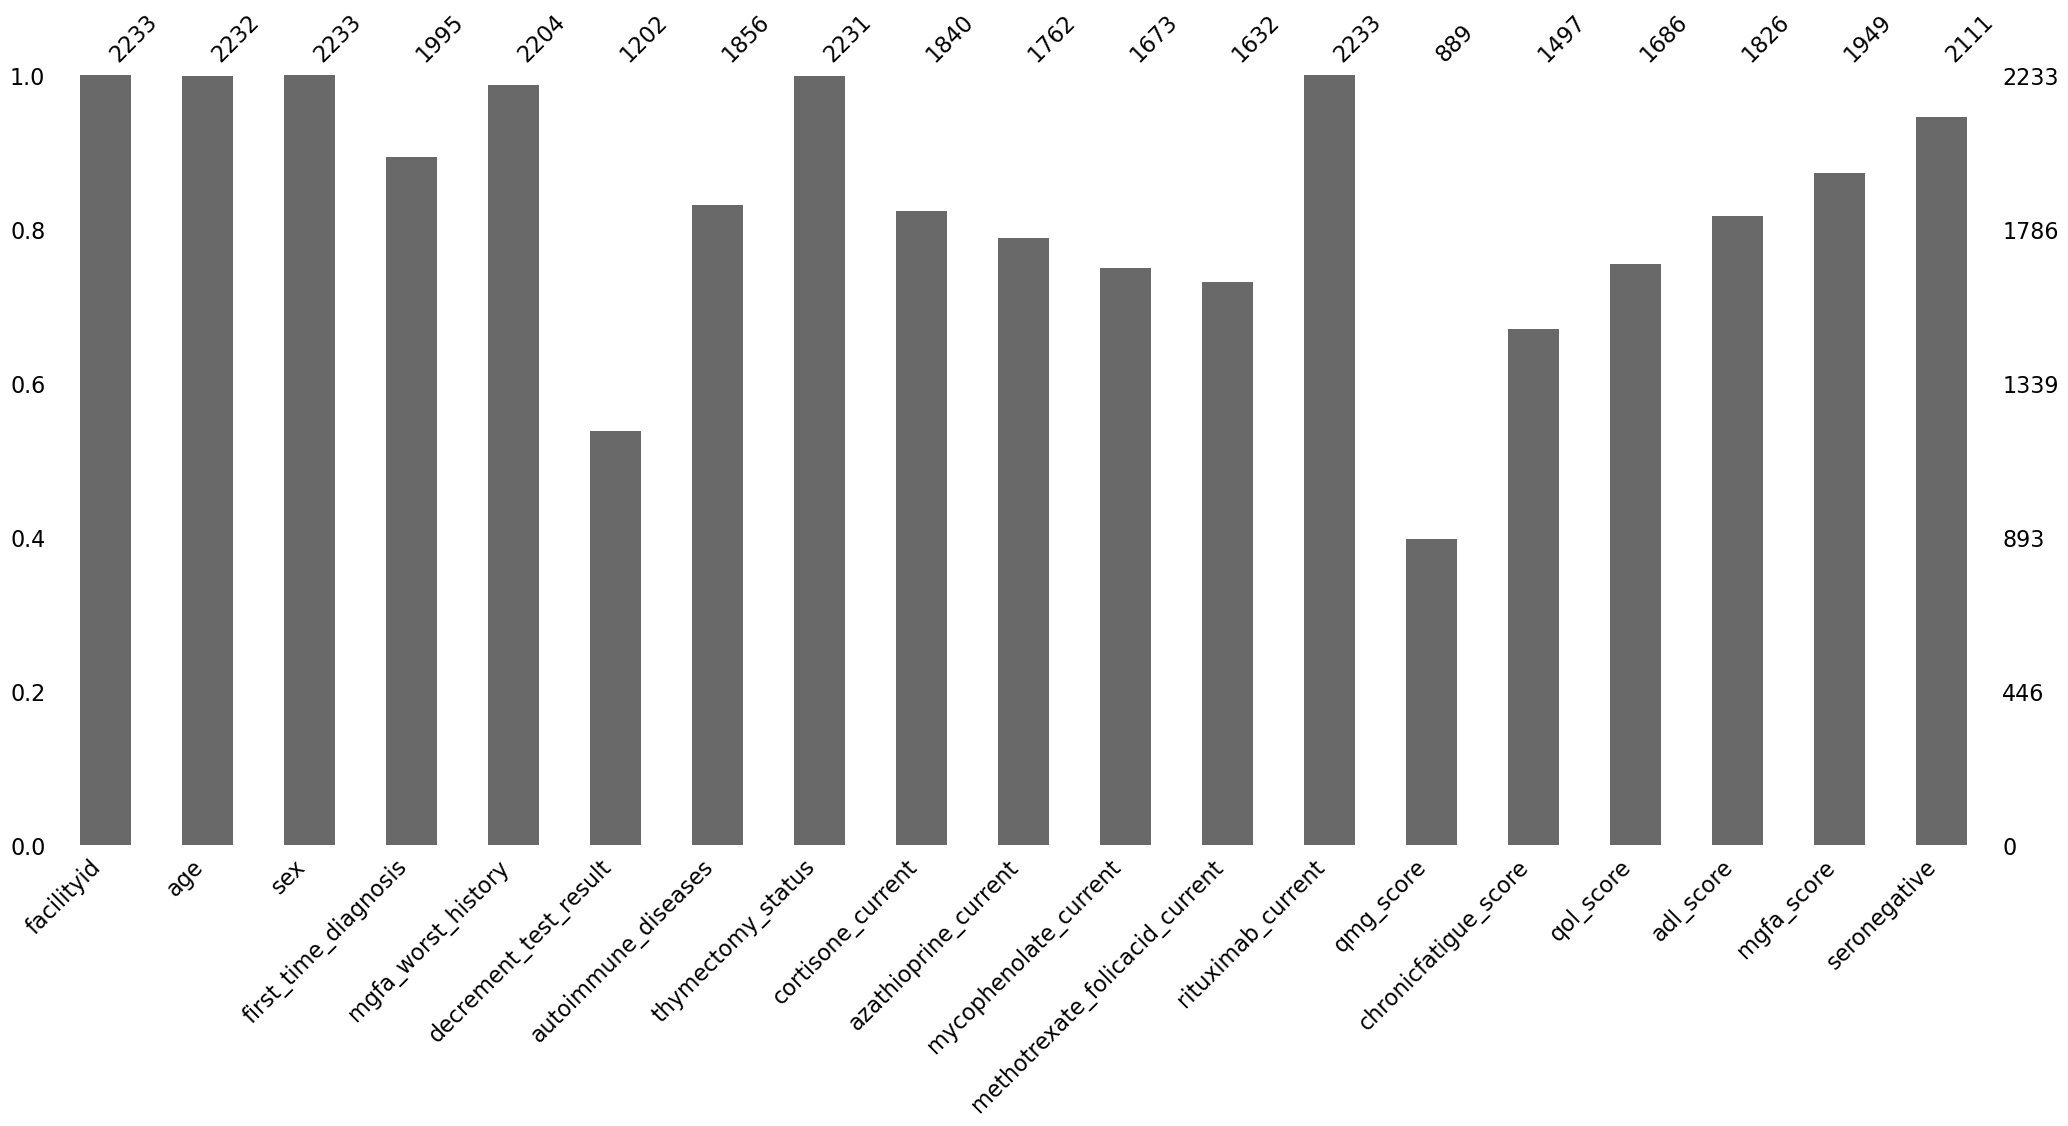

In [4]:
msno.bar(df_original)

<Axes: >

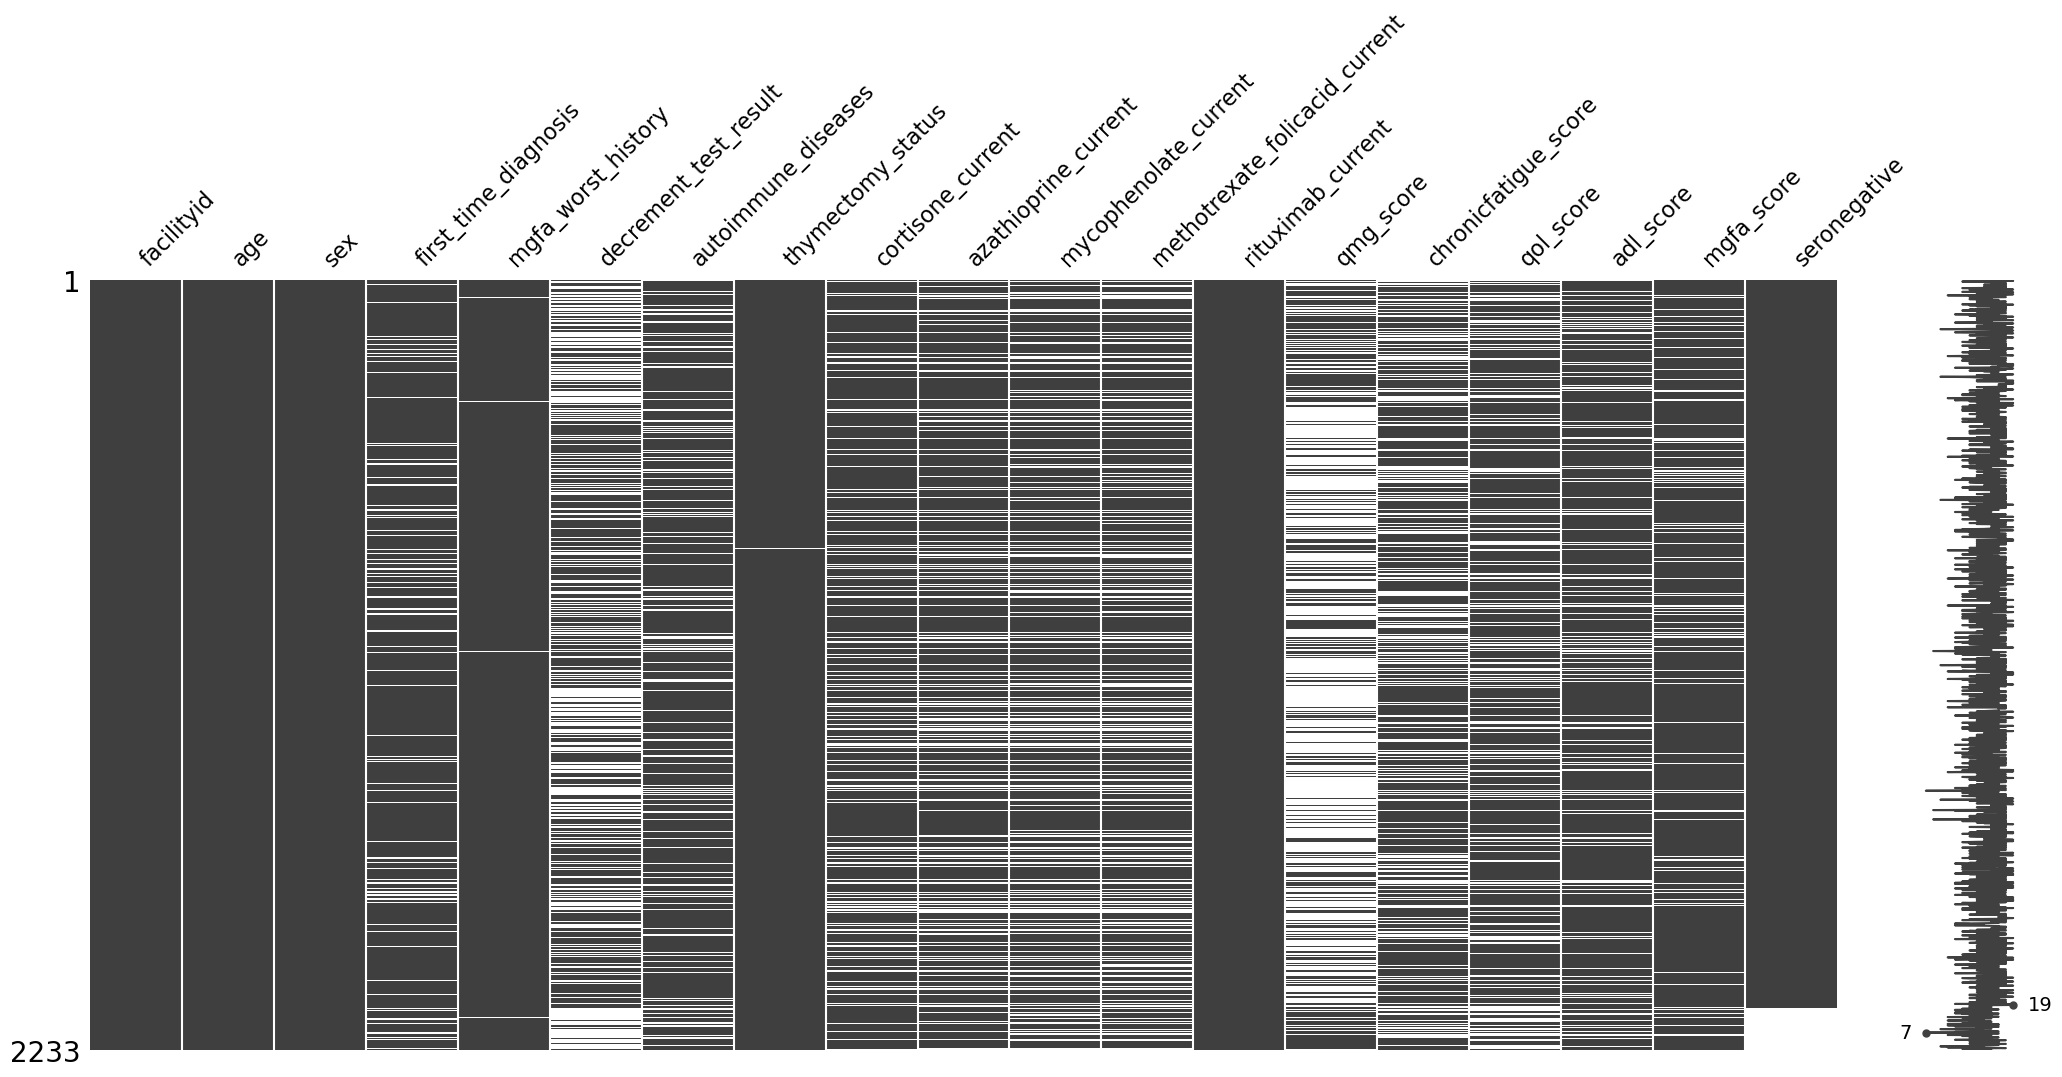

In [5]:
msno.matrix(df_original)

In [6]:
df_original['sex'].value_counts()

sex
0    1233
1    1000
Name: count, dtype: int64

# Sorting Data based on facility IDs

In [7]:
df_original['facilityid'].nunique()

20

In [8]:
df_original['facilityid'].value_counts()

facilityid
2019001    791
2019008    197
2019004    159
2019003    142
2019006    113
2019007    106
2019002    104
2019010     93
2019005     86
2019011     73
2019016     71
2019012     69
2019013     62
2019019     46
2019009     33
2019014     27
2019017     22
2019015     22
2019020     11
2019021      6
Name: count, dtype: int64

<Figure size 1400x800 with 0 Axes>

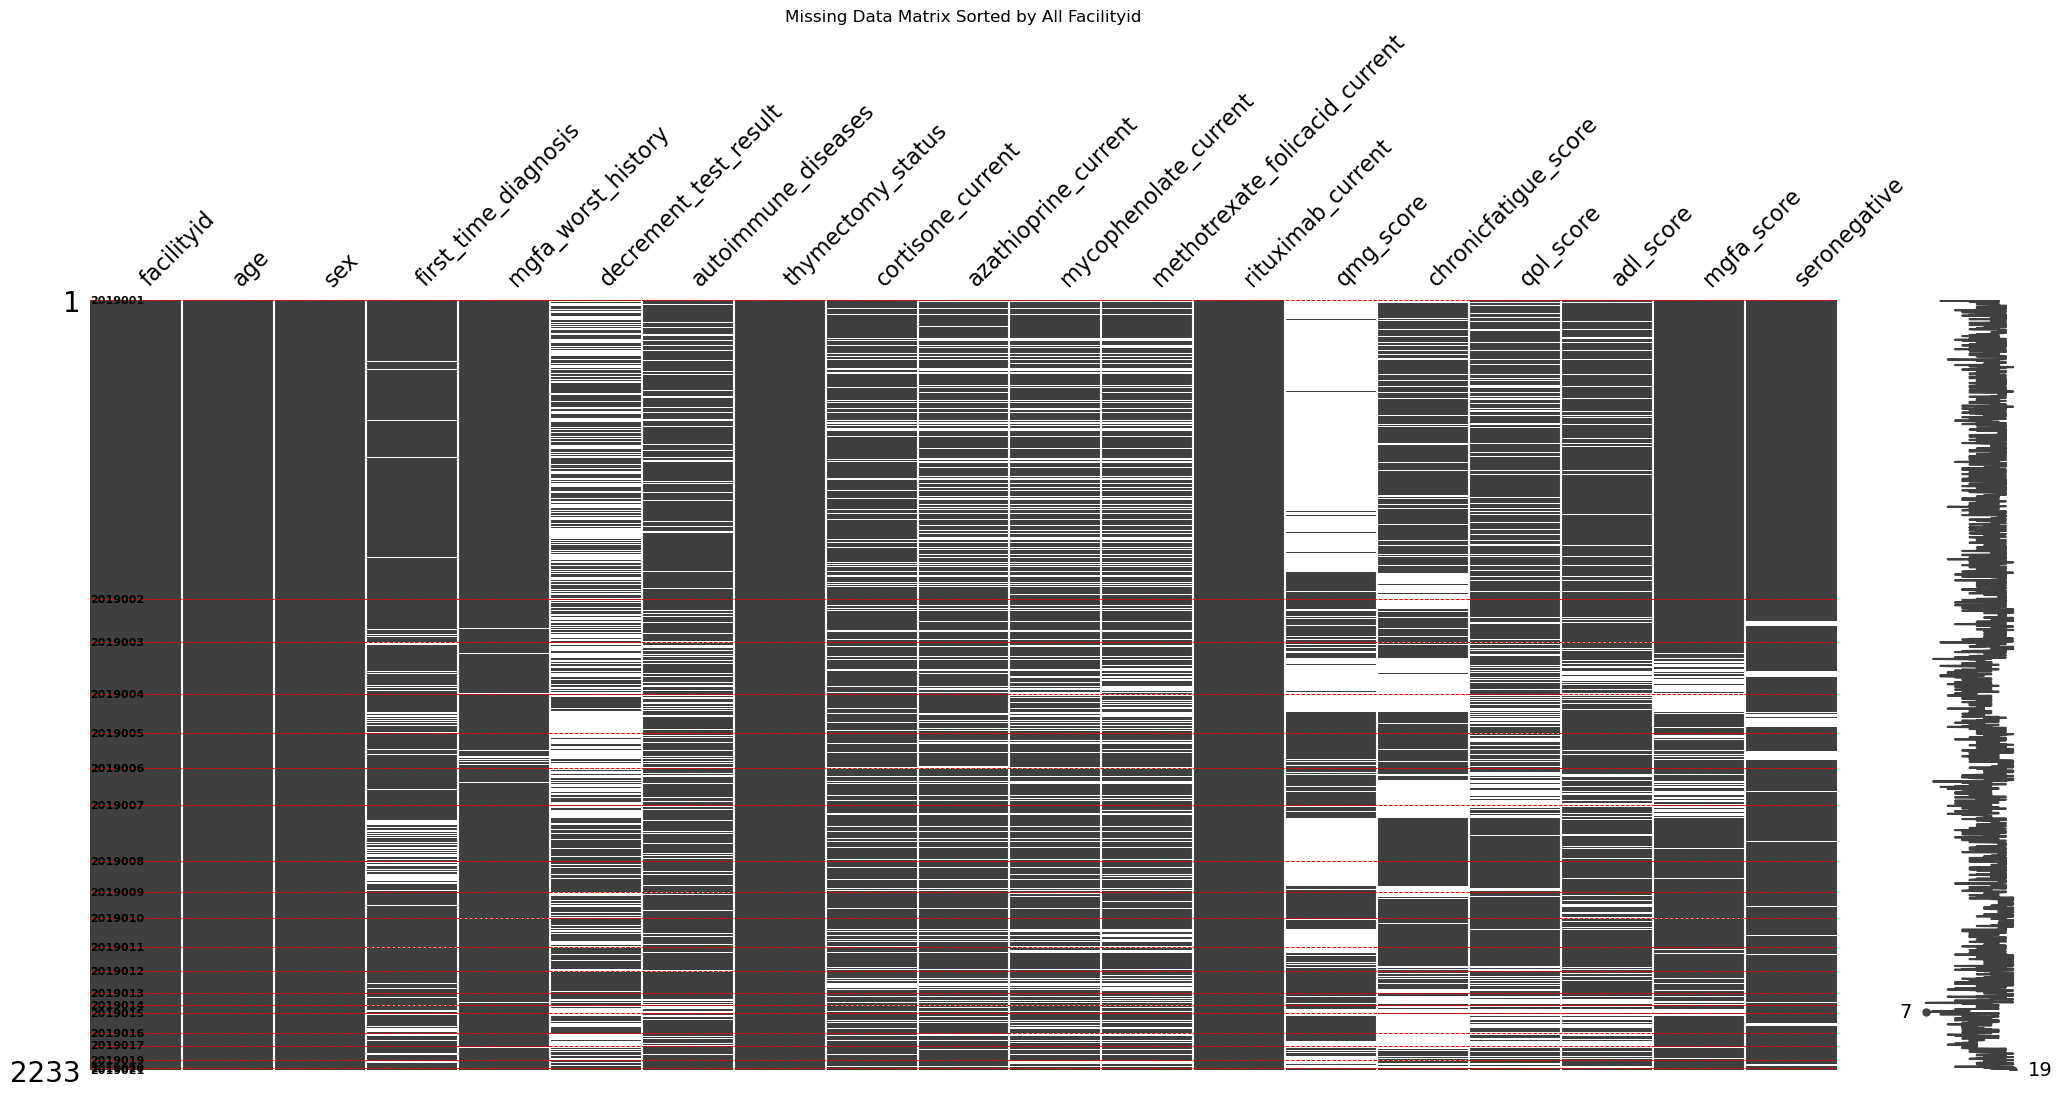

In [9]:
# List of all 20 unique facility IDs
all_facility_ids = [2019001, 2019002, 2019003, 2019004, 2019005, 2019006, 2019007, 
                    2019008, 2019009, 2019010, 2019011, 2019012, 2019013, 2019014, 
                    2019015, 2019016, 2019017, 2019019, 2019020, 2019021]

# Create a DataFrame with all facility IDs
df_facility_ids = pd.DataFrame({'facilityid': all_facility_ids})

# Merge with the original dataset, keeping all facility IDs
df_merged = df_facility_ids.merge(df_original, on='facilityid', how='left')

# Sort the merged data by 'facilityid' in ascending order
df_sorted = df_merged.sort_values(by='facilityid')

# Adjust figure size based on the number of facility IDs (20 facility IDs, so size needs to be larger)
plt.figure(figsize=(14, 8))

# Plot the missing data matrix for the full dataset (with all facility IDs)
msno.matrix(df_sorted)

# Get the first occurrence indices of each unique 'facilityid'
facility_indices = [df_sorted[df_sorted['facilityid'] == facility].index[0] for facility in all_facility_ids]

# Plot horizontal lines and mark new facilityid occurrences
for idx in facility_indices:
    plt.axhline(y=idx, color='red', linestyle='--', linewidth=0.7)  # Red line to mark new facilityid
    plt.text(-0.5, idx, df_sorted['facilityid'].iloc[idx], verticalalignment='center', 
             fontsize=8, color='black', weight='bold')

# Add a title to the plot
plt.title("Missing Data Matrix Sorted by All Facilityid")

# Show the plot
plt.show()

# Frequencies and Distributions for Original Dataset

In [10]:
# Calculate frequencies and distributions for original dataset

summary_stats= df_original.describe(include= 'all').T
summary_stats_rounded= summary_stats.round(2)
summary_stats_rounded

,count,mean,std,min,25%,50%,75%,max
facilityid,2233.0,2019005.64,5.09,2019001.0,2019001.00,2019004.00,2019008.00,2019021.00
age,2232.0,60.06,17.72,0.0,48.92,62.55,73.74,101.00
sex,2233.0,0.45,0.50,0.0,0.00,0.00,1.00,1.00
first_time_diagnosis,1995.0,1.52,3.86,0.0,0.08,0.25,1.00,46.83
mgfa_worst_history,2204.0,2.97,1.71,0.0,2.00,3.00,4.00,8.00
decrement_test_result,1202.0,0.54,0.50,0.0,0.00,1.00,1.00,1.00
autoimmune_diseases,1856.0,0.27,0.45,0.0,0.00,0.00,1.00,1.00
thymectomy_status,2231.0,0.39,0.49,0.0,0.00,0.00,1.00,1.00
cortisone_current,1840.0,0.57,0.50,0.0,0.00,1.00,1.00,1.00
azathioprine_current,1762.0,0.45,0.50,0.0,0.00,0.00,1.00,1.00


# Handling Missing Values: MICE Imputation (Decision Tree Regressor)

In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor

In [12]:
# Define the columns
continuous_columns = ['age', 'first_time_diagnosis', 'qmg_score', 'chronicfatigue_score', 'qol_score', 'adl_score']

categorical_columns = ['sex', 'mgfa_worst_history', 'decrement_test_result', 'autoimmune_diseases',
                       'thymectomy_status', 'cortisone_current', 'azathioprine_current', 'mycophenolate_current', 
                       'methotrexate_folicacid_current', 'mgfa_score', 'seronegative']

# Custom function for rounding categorical variables
def round_categorical(imputed_data, categorical_columns):
    imputed_data[categorical_columns] = imputed_data[categorical_columns].round().astype(int)
    return imputed_data

# Custom function to enforce non-negative values on continuous columns
def enforce_non_negative(df, continuous_columns):
    df[continuous_columns] = df[continuous_columns].applymap(lambda x: max(x, 0))
    return df

In [13]:
# Tune DecisionTreeRegressor
dt_estimator = DecisionTreeRegressor(max_depth=20,        
                                     min_samples_split=5,
                                     min_samples_leaf=3,
                                     random_state=0)

# Initialize the MICE imputer with tuned DecisionTreeRegressor
mice_imputer = IterativeImputer(estimator=dt_estimator, 
                                max_iter=30,
                                random_state=0, 
                                tol=1e-4, 
                                n_nearest_features=10,
                                initial_strategy='median')

In [14]:
# Fit and transform the dataset (df_original)
df_imputed = mice_imputer.fit_transform(df_original)

# Convert the imputed result back to a DataFrame
df_imputed = pd.DataFrame(df_imputed, columns=df_original.columns)

# Apply rounding to categorical variables
df_imputed = round_categorical(df_imputed, categorical_columns)

# Enforce non-negative values on continuous columns post-imputation
df_imputed = enforce_non_negative(df_imputed, continuous_columns)

# Output the imputed dataset
df_imputed_dataset = df_imputed

/var/folders/x0/0d0s17_j0ngcgcjy71h5nc4m0000gn/T/ipykernel_89010/4176892133.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[continuous_columns] = df[continuous_columns].applymap(lambda x: max(x, 0))


In [15]:
df_imputed_dataset.head()

,facilityid,age,sex,first_time_diagnosis,mgfa_worst_history,decrement_test_result,autoimmune_diseases,thymectomy_status,cortisone_current,azathioprine_current,mycophenolate_current,methotrexate_folicacid_current,rituximab_current,qmg_score,chronicfatigue_score,qol_score,adl_score,mgfa_score,seronegative
0,2019009.0,34.961111,0,0.166667,8,1,0,1,0,0,0,0,0.0,0.0,13.6,12.250000,2.00,3,0
1,2019006.0,59.711111,1,3.166667,2,1,0,0,0,0,1,0,0.0,1.0,13.6,11.333333,6.00,2,0
2,2019010.0,83.344444,1,0.250000,5,0,1,0,0,0,1,0,0.0,5.0,12.0,7.000000,3.00,2,0
3,2019019.0,56.505556,1,0.083333,2,0,0,0,1,1,0,0,0.0,4.0,8.0,15.600000,5.25,2,0
4,2019004.0,39.986111,0,0.000000,5,1,1,0,0,1,0,0,0.0,4.6,10.0,10.000000,1.00,3,0


In [16]:
# Calculate frequencies and distributions for original dataset

summary_stats= df_imputed_dataset.describe(include= 'all').T
summary_stats_rounded= summary_stats.round(2)
summary_stats_rounded

,count,mean,std,min,25%,50%,75%,max
facilityid,2233.0,2019005.64,5.09,2019001.0,2019001.00,2019004.00,2019008.00,2019021.00
age,2233.0,60.06,17.72,0.0,48.89,62.53,73.73,101.00
sex,2233.0,0.45,0.50,0.0,0.00,0.00,1.00,1.00
first_time_diagnosis,2233.0,1.50,3.73,0.0,0.08,0.25,1.00,46.83
mgfa_worst_history,2233.0,2.97,1.70,0.0,2.00,3.00,4.00,8.00
decrement_test_result,2233.0,0.55,0.50,0.0,0.00,1.00,1.00,1.00
autoimmune_diseases,2233.0,0.26,0.44,0.0,0.00,0.00,1.00,1.00
thymectomy_status,2233.0,0.39,0.49,0.0,0.00,0.00,1.00,1.00
cortisone_current,2233.0,0.57,0.49,0.0,0.00,1.00,1.00,1.00
azathioprine_current,2233.0,0.45,0.50,0.0,0.00,0.00,1.00,1.00


# Plotting the distributions of continuous variables for both original and imputed data

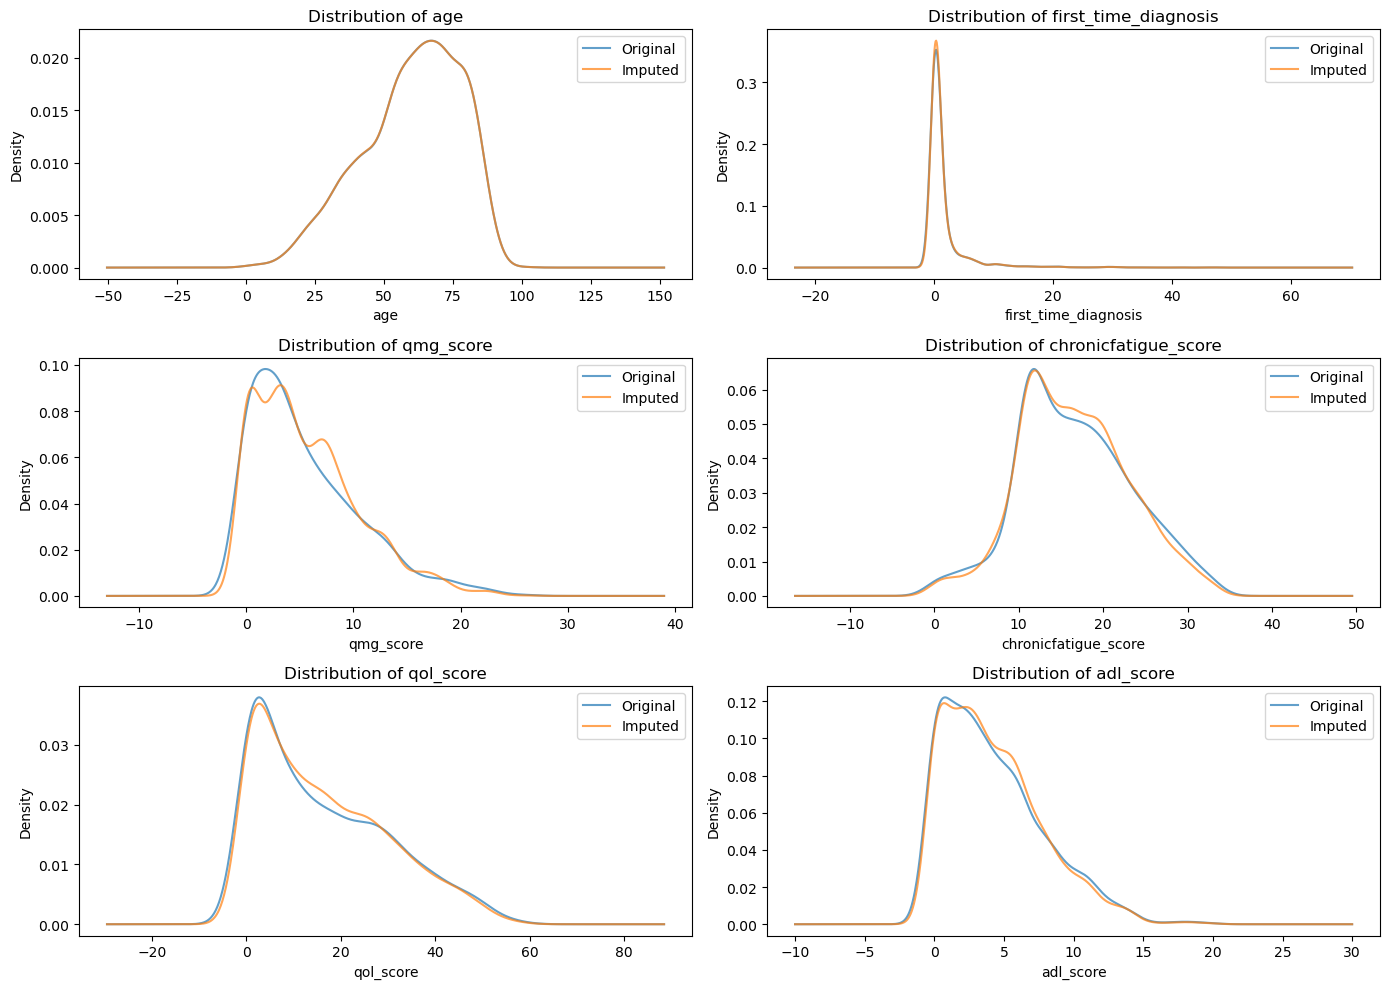

In [17]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(continuous_columns):
    plt.subplot(3, 2, i+1)
    df_original[col].plot(kind='density', label='Original', alpha=0.7)
    df_imputed_dataset[col].plot(kind='density', label='Imputed', alpha=0.7)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.legend()

plt.tight_layout()
plt.show()

# Plotting the distributions of categorical variables for both original and imputed data

In [18]:
categorical_columns_1 = [
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current'
]

categorical_columns_2 = [
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'mgfa_score',
    'seronegative'
]

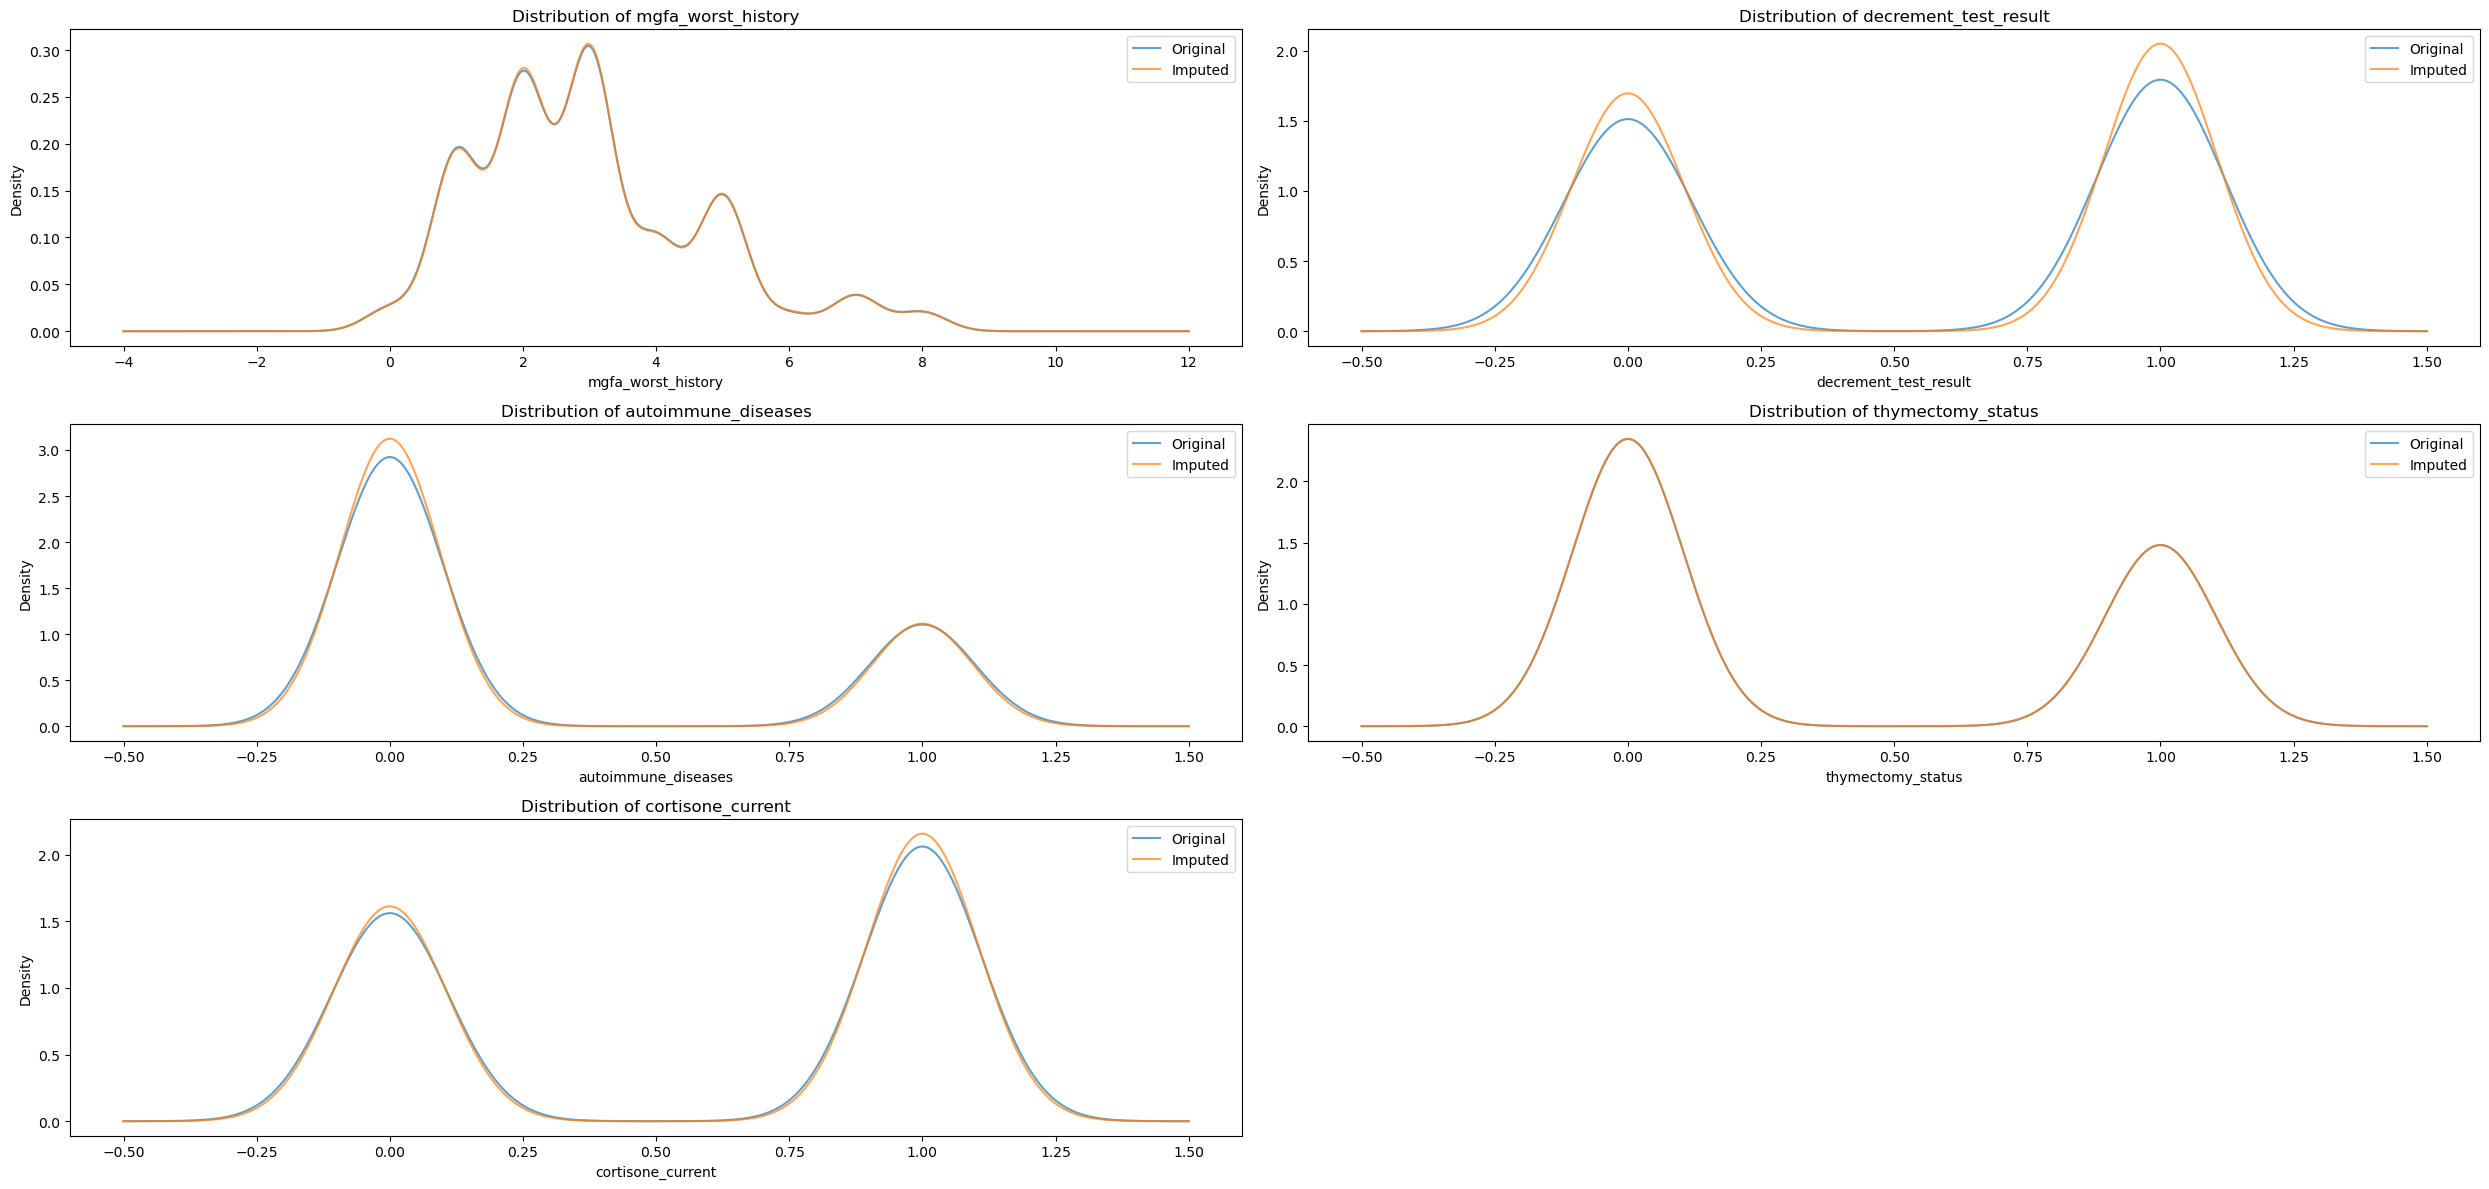

In [19]:
plt.figure(figsize=(25, 12))

for i, col in enumerate(categorical_columns_1):
    plt.subplot(3, 2, i+1)
    df_original[col].plot(kind='density', label='Original', alpha=0.7)
    df_imputed_dataset[col].plot(kind='density', label='Imputed', alpha=0.7)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.legend()

plt.tight_layout()
plt.show()

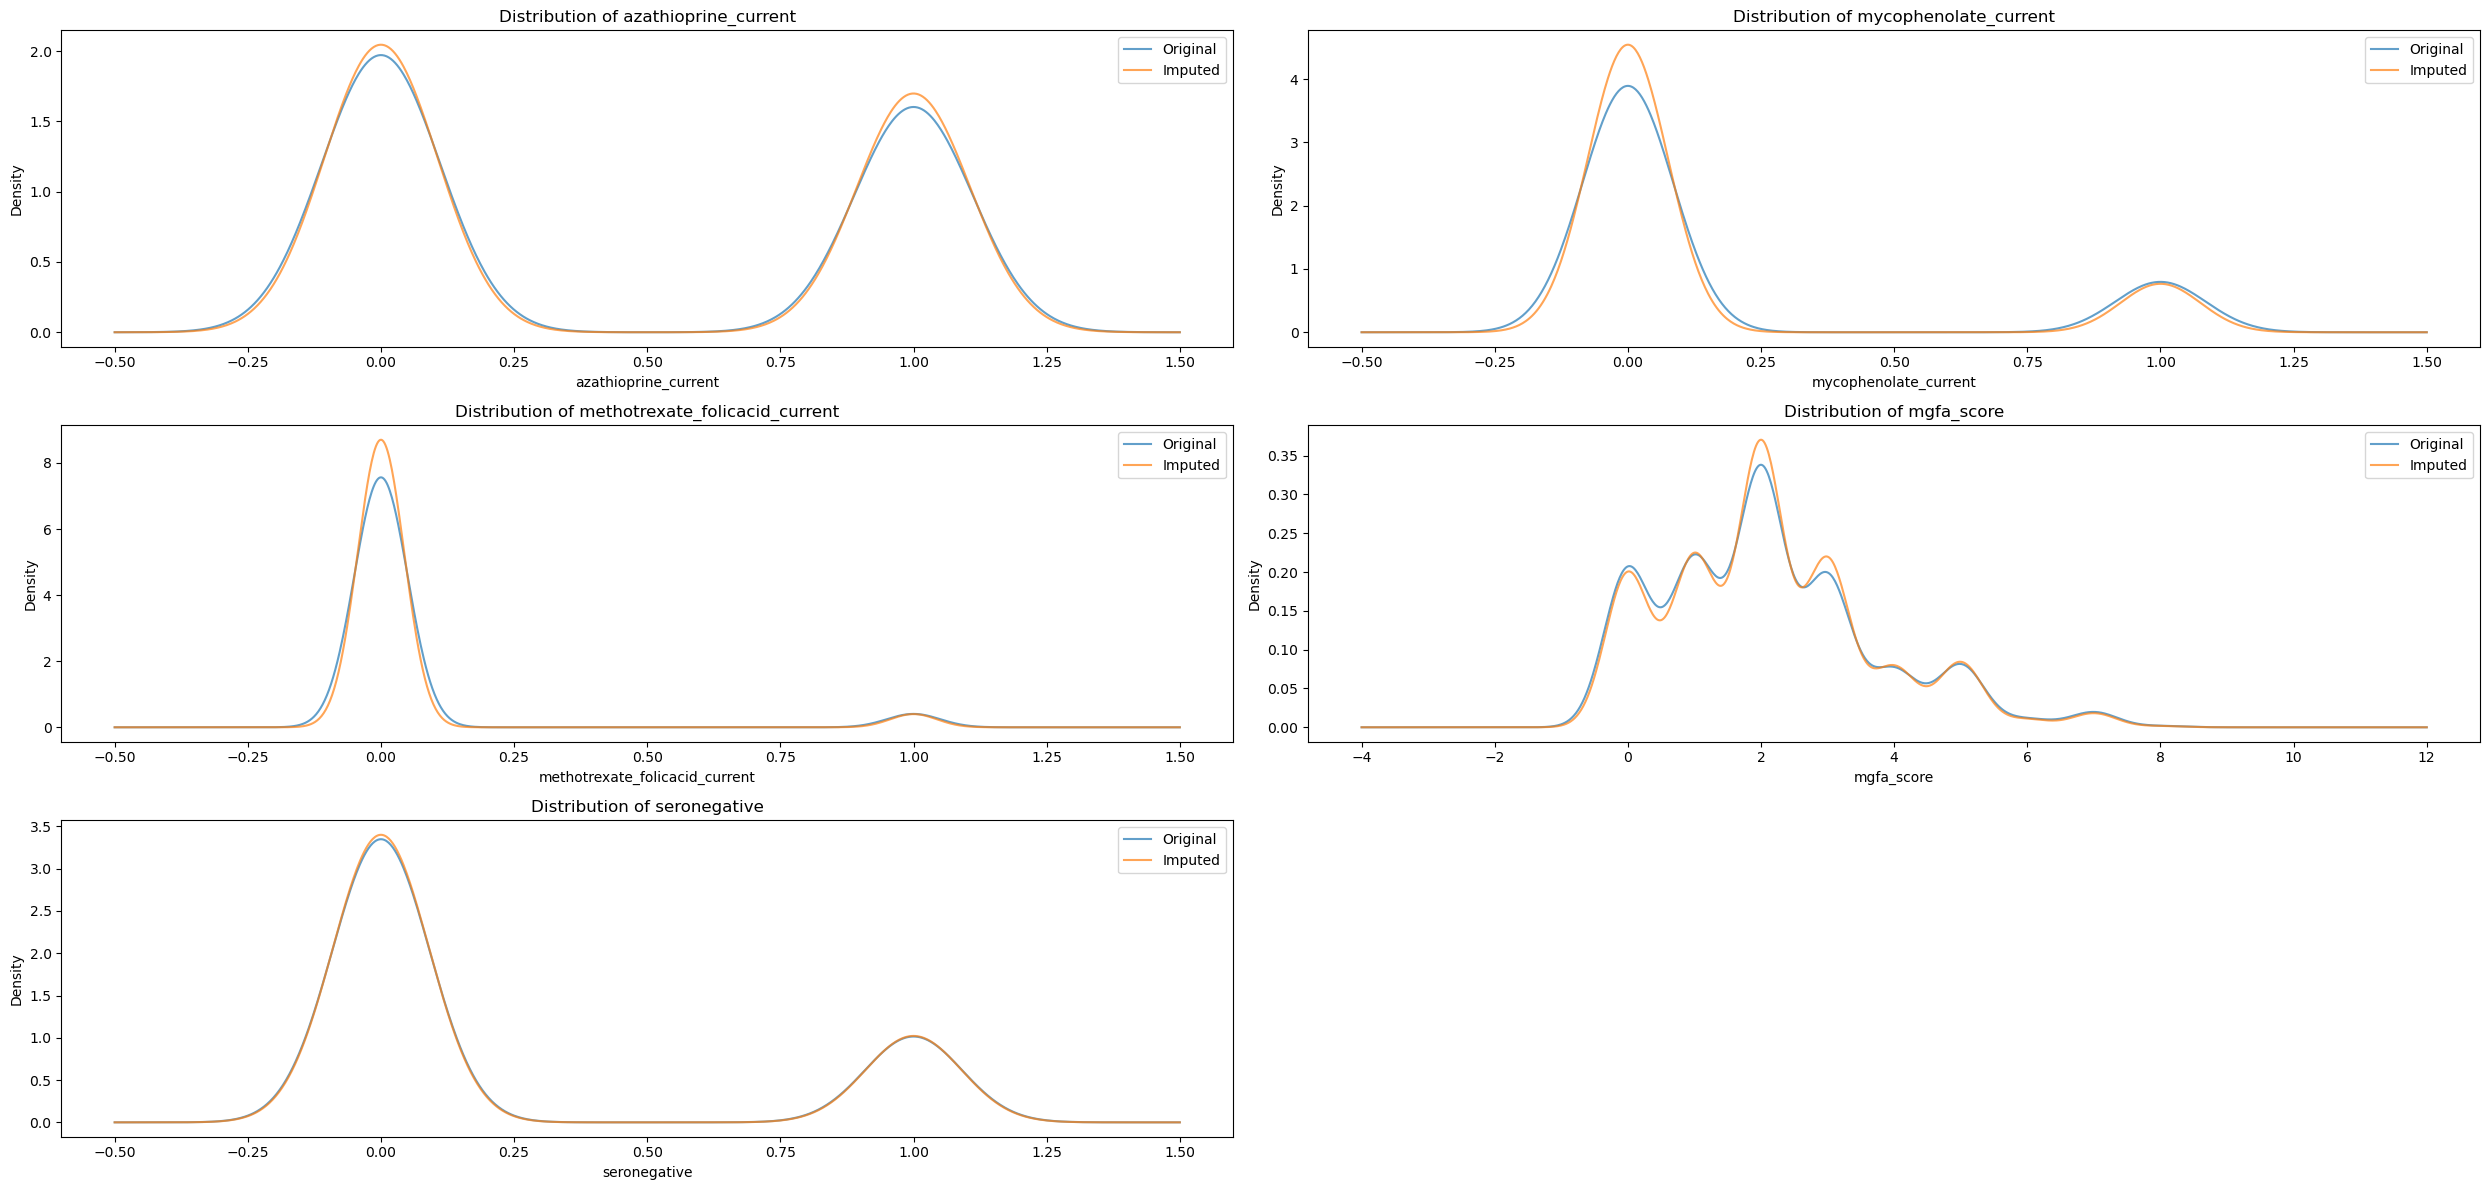

In [20]:
plt.figure(figsize=(25, 12))

for i, col in enumerate(categorical_columns_2):
    plt.subplot(3, 2, i+1)
    df_original[col].plot(kind='density', label='Original', alpha=0.7)
    df_imputed_dataset[col].plot(kind='density', label='Imputed', alpha=0.7)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.legend()

plt.tight_layout()
plt.show()

# Plotting for score columns

In [21]:
# Score Columns
score_columns = [
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score',
    'mgfa_score'
]

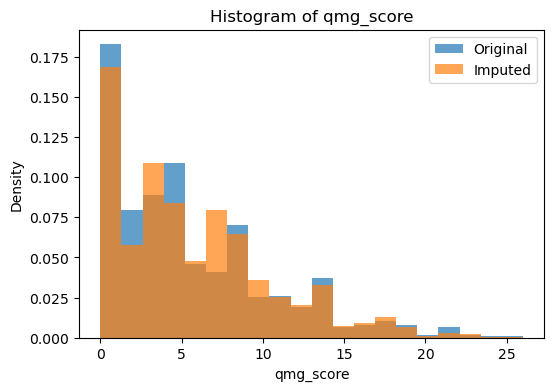

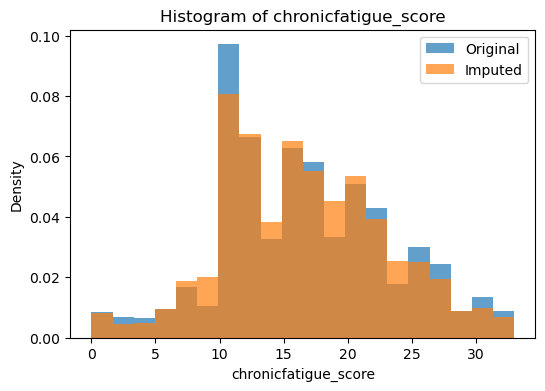

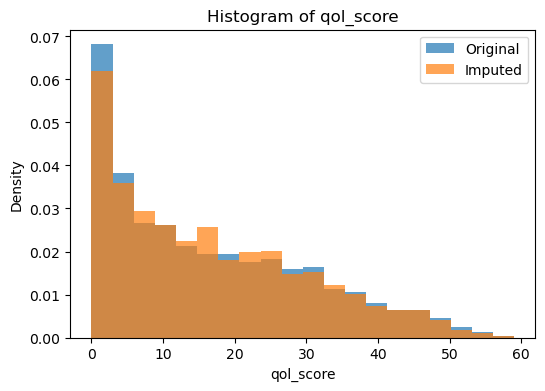

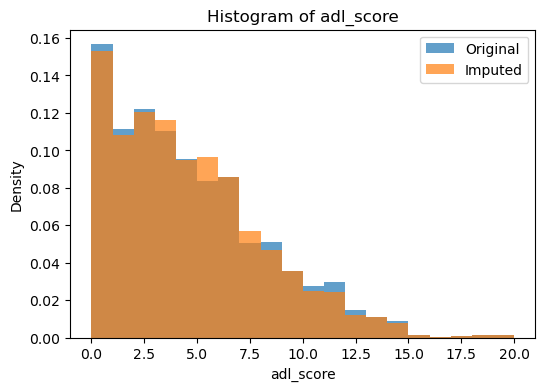

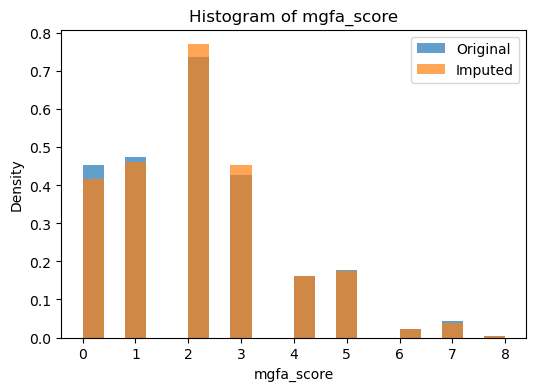

In [22]:
# Plotting histograms for each score column separately
for col in score_columns:
    plt.figure(figsize=(6, 4))
    df_original[col].plot(kind='hist', bins=20, alpha=0.7, label='Original', density=True)
    df_imputed_dataset[col].plot(kind='hist', bins=20, alpha=0.7, label='Imputed', density=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

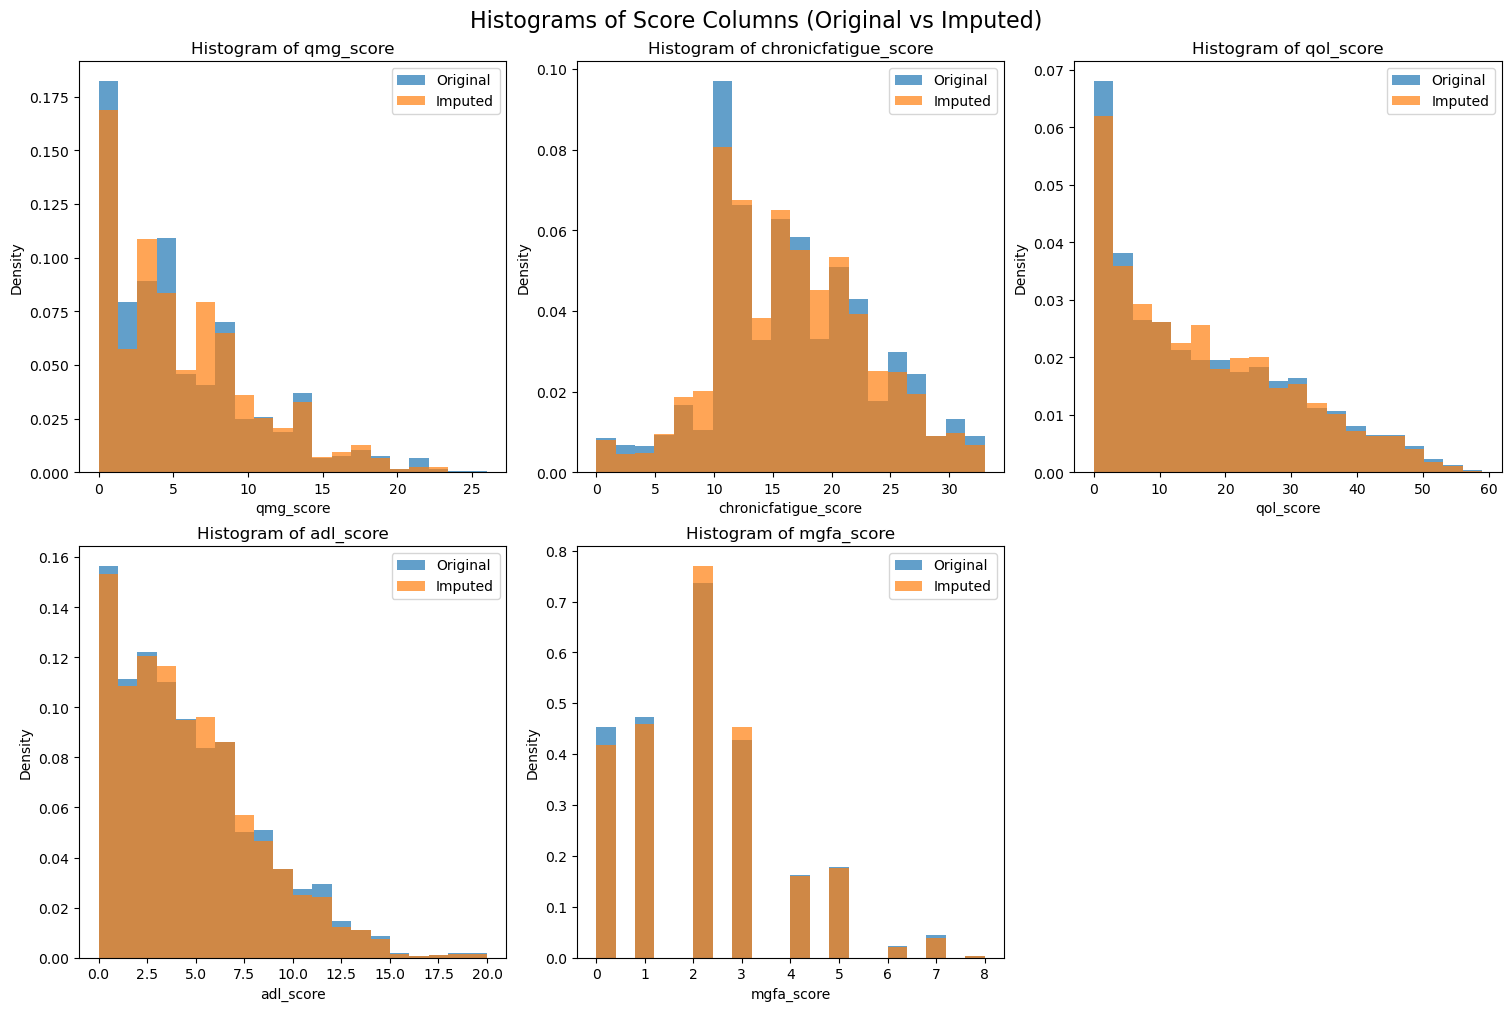

In [23]:
# Define the number of columns for subplots (adjust based on the number of score columns)
n_cols = 3 
n_rows = -(-len(score_columns) // n_cols)

# Create a figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), constrained_layout=True)

# Flatten axes for easy indexing, handle if fewer plots than grid
axes = axes.flatten()

# Plot each score column in its respective subplot
for i, col in enumerate(score_columns):
    ax = axes[i]
    df_original[col].plot(kind='hist', bins=20, alpha=0.7, label='Original', density=True, ax=ax)
    df_imputed_dataset[col].plot(kind='hist', bins=20, alpha=0.7, label='Imputed', density=True, ax=ax)
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

# Remove unused subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Score Columns (Original vs Imputed)', fontsize=16)
plt.show()

# Box Plot between score variables and 'seronegative' for both Original and Imputed data

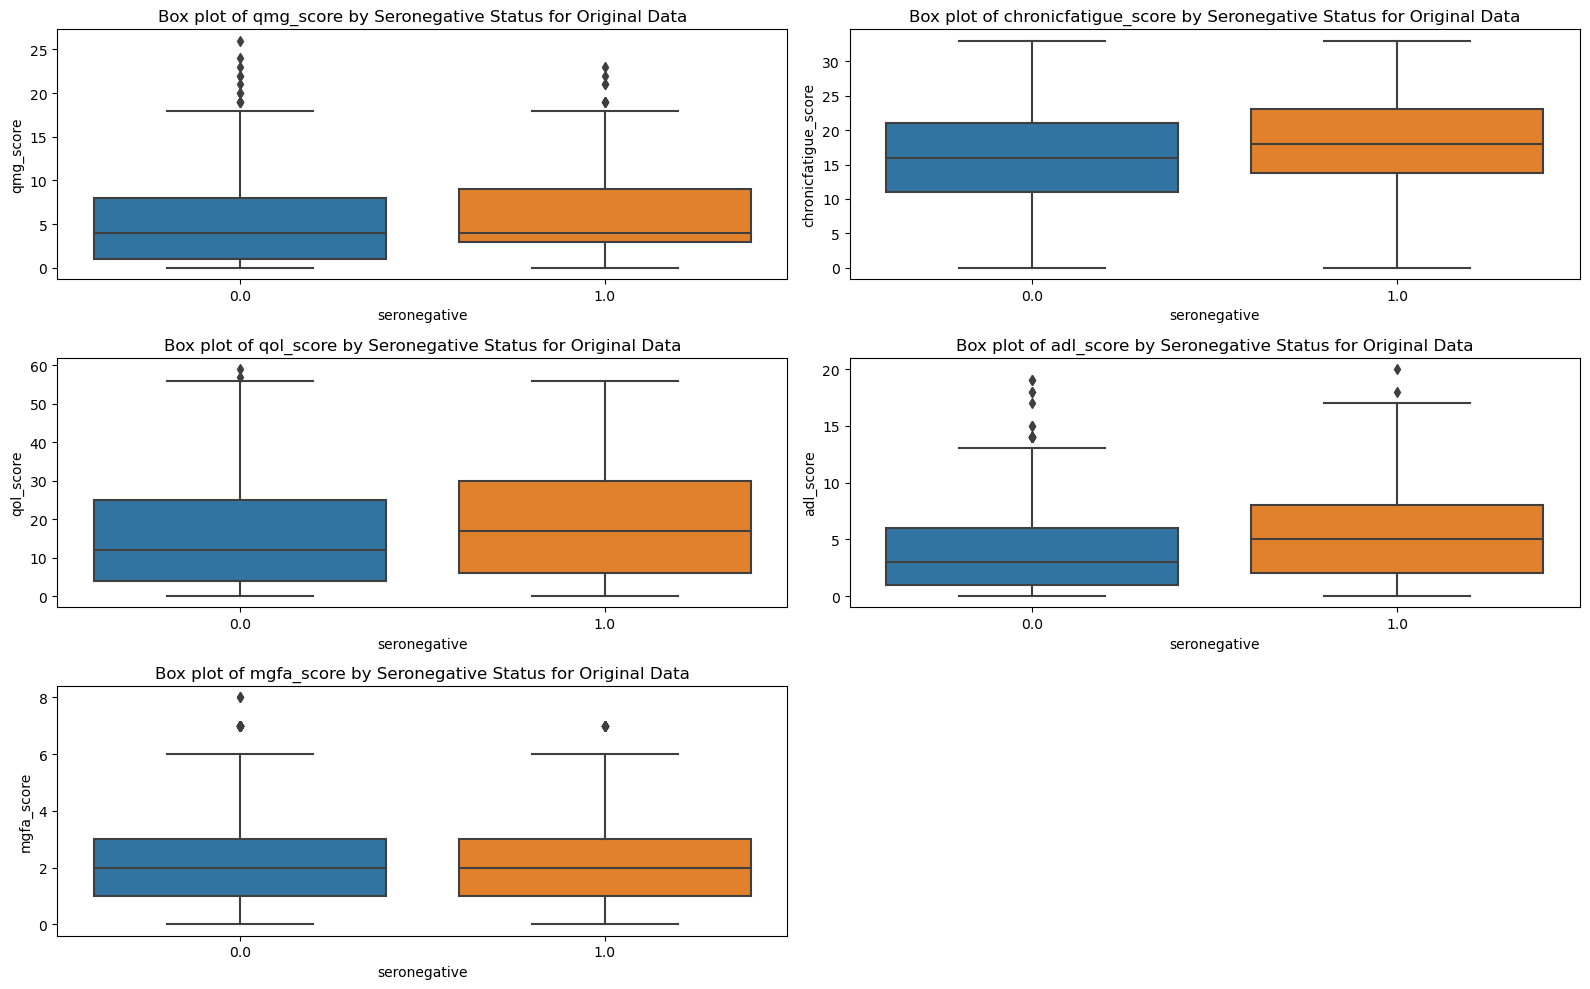

In [24]:
# Plotting boxplots for original data
plt.figure(figsize=(16, 10))

for i, col in enumerate(score_columns):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x='seronegative', y=col, data=df_original)
    plt.title(f'Box plot of {col} by Seronegative Status for Original Data')

plt.tight_layout()
plt.show()

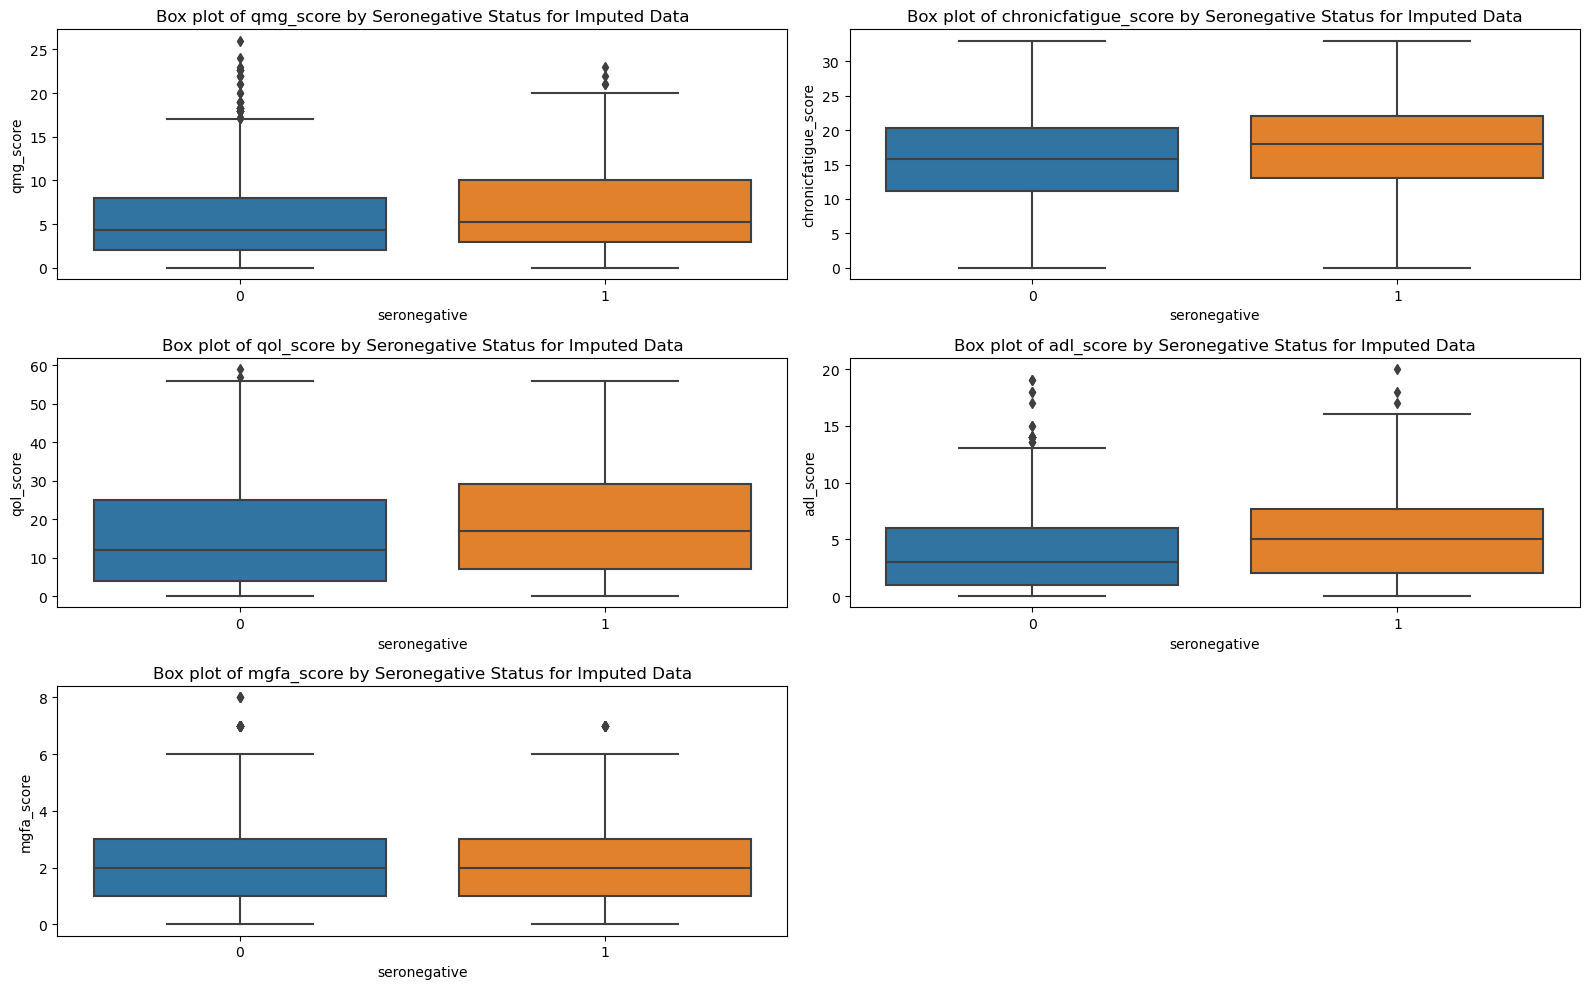

In [25]:
# Plotting boxplots for imputed data
plt.figure(figsize=(16, 10))

for i, col in enumerate(score_columns):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x='seronegative', y=col, data=df_imputed_dataset)
    plt.title(f'Box plot of {col} by Seronegative Status for Imputed Data')

plt.tight_layout()
plt.show()

# Correlation Matrix using a heatmap for Original & Imputed dataset

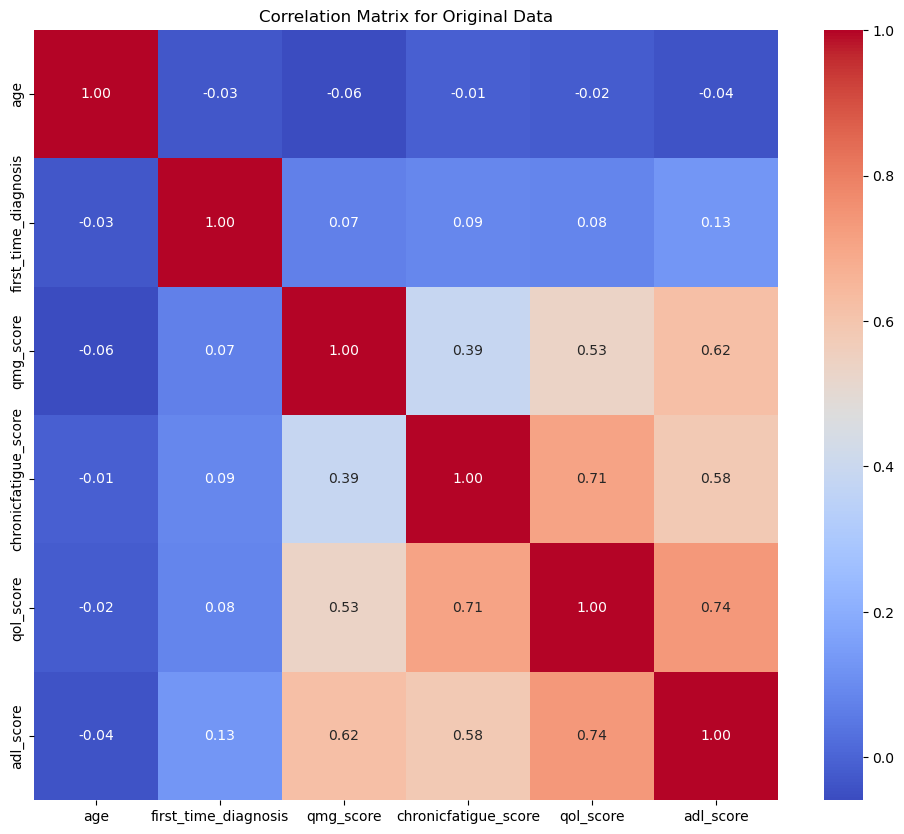

In [26]:
columns_of_check = [
    'age',
    'first_time_diagnosis',
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score'
]

df_subset = df_original[columns_of_check]

correlation_matrix = df_subset.corr()

# Visualizing the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Original Data")
plt.show()

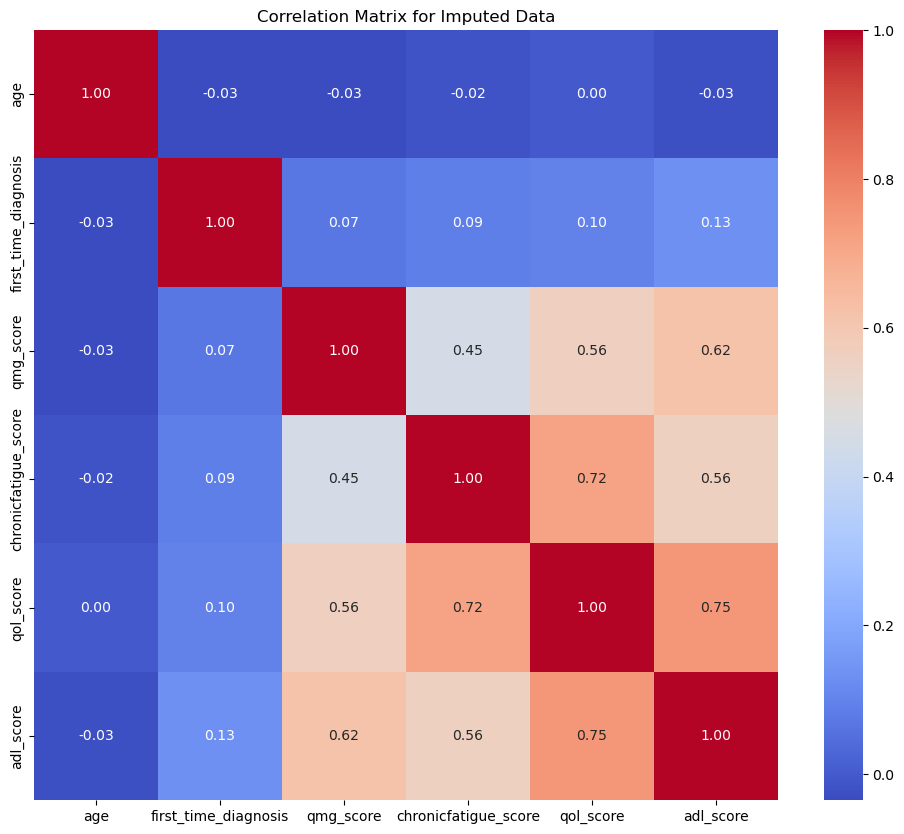

In [27]:
columns_of_check = [
    'age',
    'first_time_diagnosis',
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score'
]

df_subset = df_imputed_dataset[columns_of_check]

correlation_matrix = df_subset.corr()

# Visualizing the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Imputed Data")
plt.show()

# Linear Regression for Original Data

In [28]:
df_cleaned= df_original.dropna()

<Axes: >

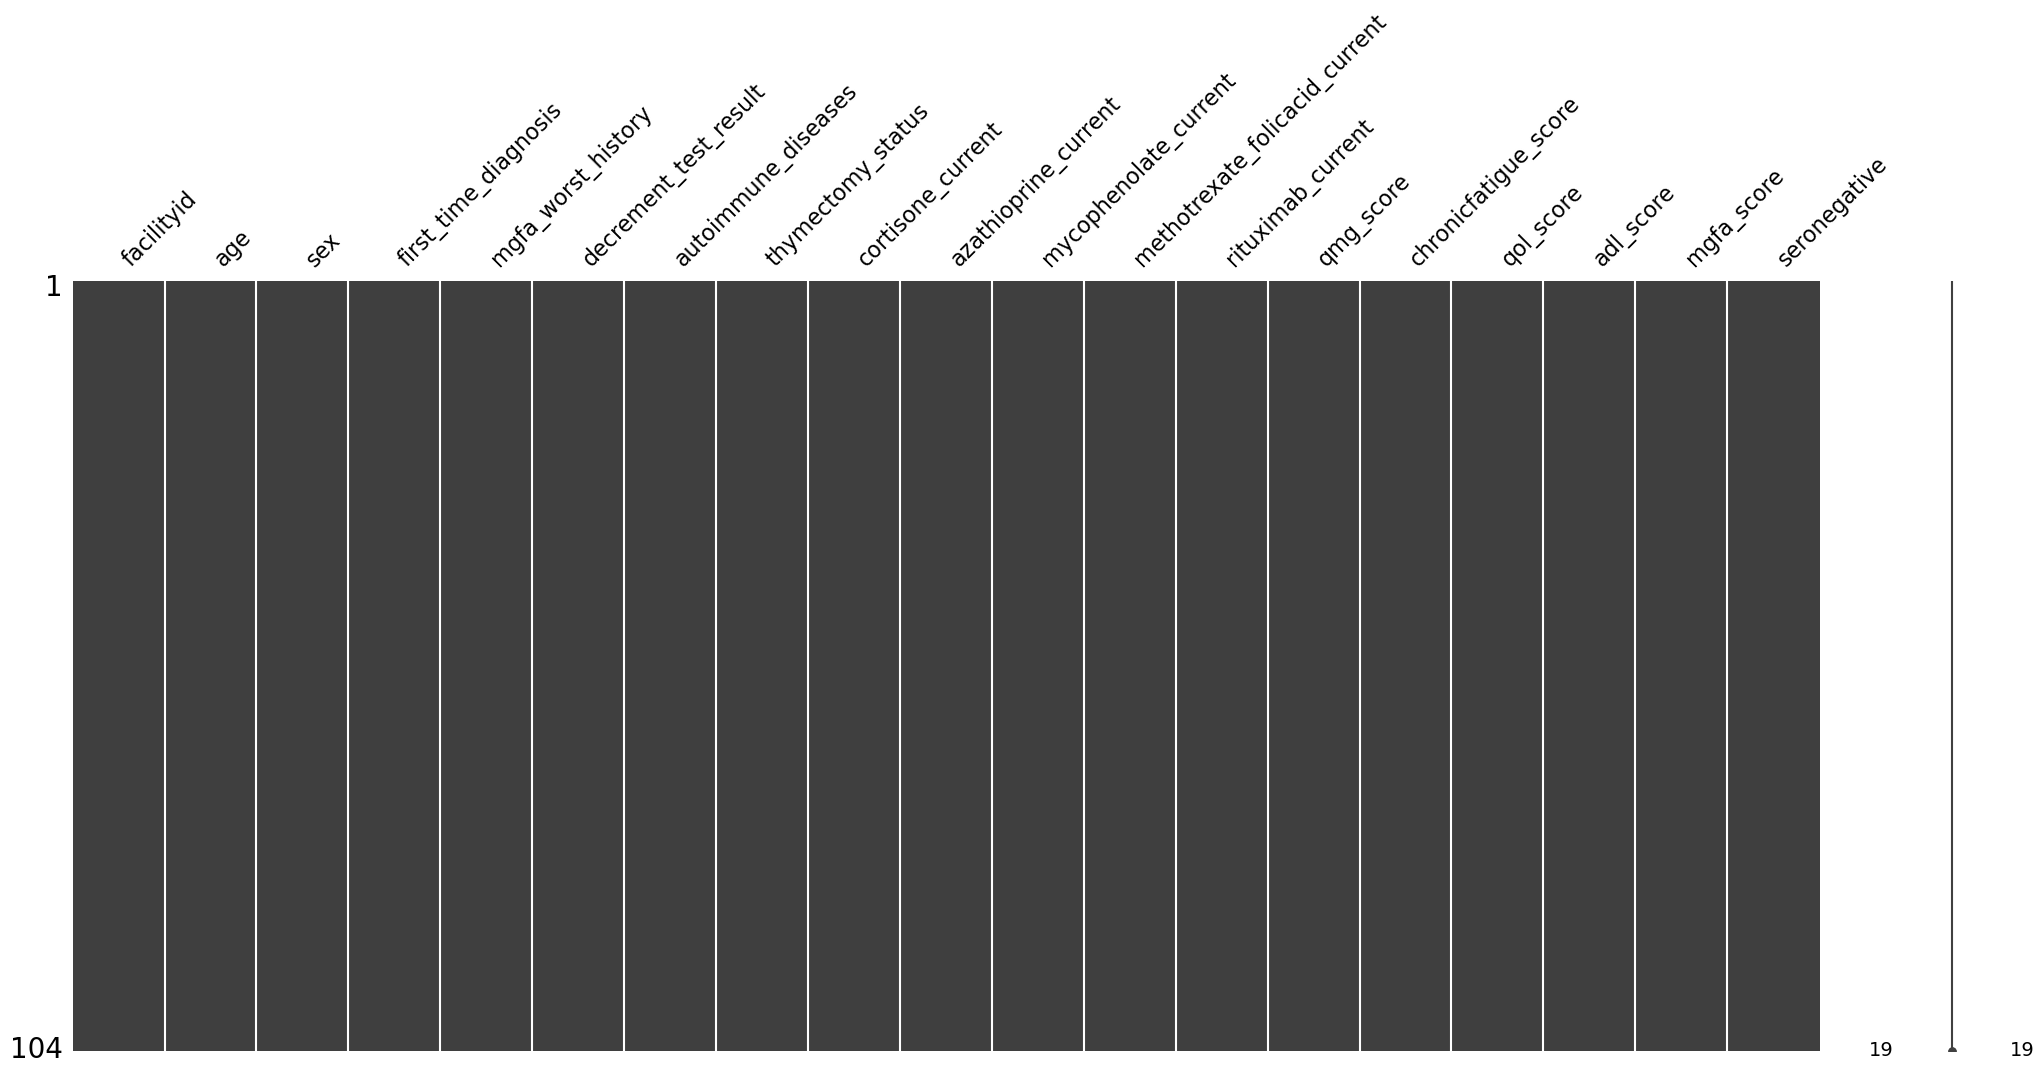

In [29]:
msno.matrix(df_cleaned)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
# Updated feature names
feature = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'seronegative'
]

# Updated target (outcome) names
targets = [
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score',
    'mgfa_score'
]

# Store coefficients in a list for visualization
coefficients = []

# Loop through each target and fit a separate regression model
for target in targets:
    model = LinearRegression()

    # Select predictors and target
    X = df_cleaned[feature]
    y = df_cleaned[target]
    
    # Fit the model
    model.fit(X, y)
    
    # Store first coefficient (if your regression has multiple features
    coefficient = model.coef_[0]
    coefficients.append(coefficient)

# Create a DataFrame for the coefficients
coefficients_df = pd.DataFrame({
    'Target': targets,
    'Coefficient': coefficients
})

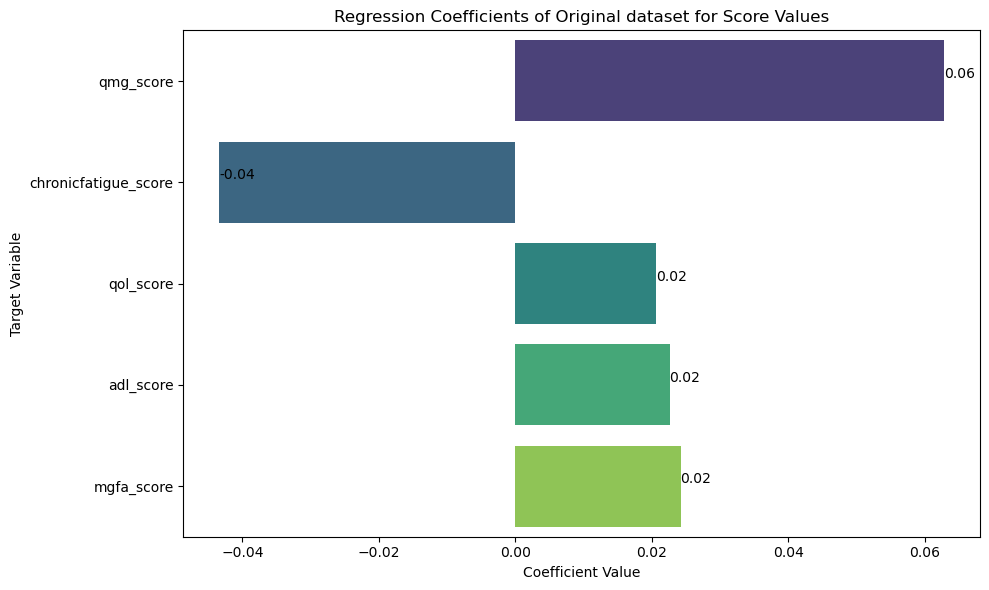

In [32]:
# Plotting the coefficients as a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Target', data=coefficients_df, orient='h', palette='viridis')

# Add labels and title
plt.title('Regression Coefficients of Original dataset for Score Values')
plt.xlabel('Coefficient Value')
plt.ylabel('Target Variable')

# Add numerical values on the bars
for index, value in enumerate(coefficients_df['Coefficient']):
    plt.text(value, index, f'{value:.2f}', va='bottom', color='black')

# Display the plot
plt.tight_layout()
plt.show()

# Linear Regression for Imputed Data

In [33]:
feature = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'seronegative'
]
targets = [
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score',
    'mgfa_score'
]
for target in targets:
    model = LinearRegression()

    X = df_imputed_dataset[feature]
    y = df_imputed_dataset[target]

    model.fit(X, y)

    # Print results
    print(f"Regression Model Coefficients for target: {target}")
    
    for feat_name, coef in zip(feature, model.coef_):
        print(f"  {feat_name}: {coef:.4f}")

    print("-" * 40)

Regression Model Coefficients for target: qmg_score
  facilityid: -0.0130
  age: 0.0006
  sex: -1.1806
  first_time_diagnosis: 0.0352
  mgfa_worst_history: 1.0528
  decrement_test_result: -0.2491
  autoimmune_diseases: -0.0910
  thymectomy_status: -0.1715
  cortisone_current: 1.6000
  azathioprine_current: 0.3131
  mycophenolate_current: 0.8746
  methotrexate_folicacid_current: -0.3293
  rituximab_current: 0.9979
  seronegative: 0.9697
----------------------------------------
Regression Model Coefficients for target: chronicfatigue_score
  facilityid: -0.0264
  age: 0.0044
  sex: -1.3551
  first_time_diagnosis: 0.0873
  mgfa_worst_history: 0.7989
  decrement_test_result: -0.5918
  autoimmune_diseases: -0.0066
  thymectomy_status: -0.3431
  cortisone_current: 1.4522
  azathioprine_current: 0.4680
  mycophenolate_current: 1.0894
  methotrexate_folicacid_current: 1.0656
  rituximab_current: 0.4345
  seronegative: 1.3596
----------------------------------------
Regression Model Coefficient

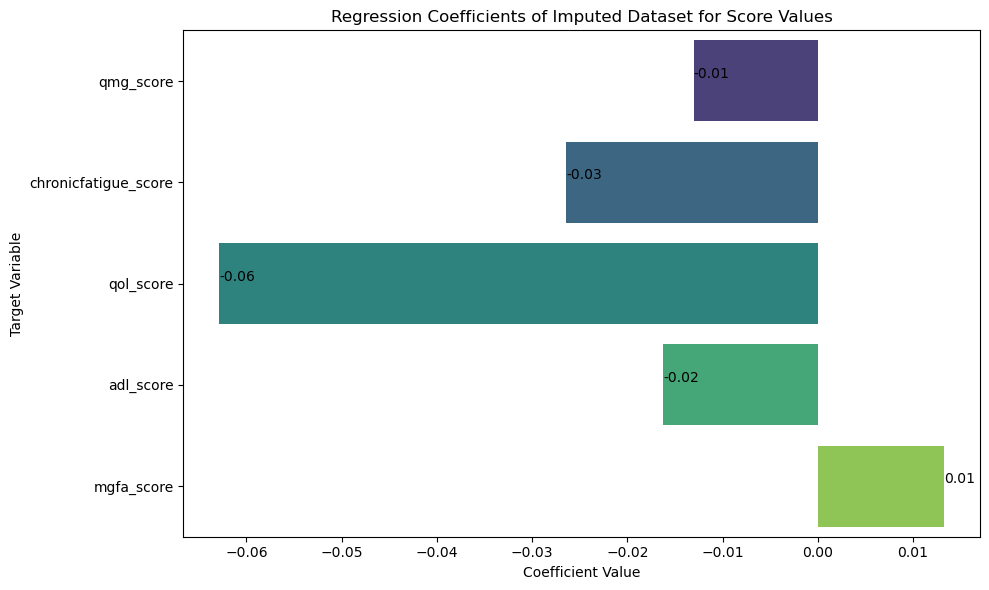

In [34]:
# Define the feature and targets (updated names)
feature = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'seronegative'
]

targets = [
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score',
    'mgfa_score'
]

# Store coefficients in a list for visualization
coefficients = []

# Loop through each target and fit a separate regression model
for target in targets:
    model = LinearRegression()

    # Select features and target
    X = df_imputed_dataset[feature]
    y = df_imputed_dataset[target]

    # Fit the regression model
    model.fit(X, y)

    # Extract the first coefficient (if multiple features)
    coefficient = model.coef_[0]

    # Store the coefficient
    coefficients.append(coefficient)

# Create a DataFrame for visualization
coefficients_df = pd.DataFrame({
    'Target': targets,
    'Coefficient': coefficients
})

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Coefficient',
    y='Target',
    data=coefficients_df,
    orient='h',
    palette='viridis'
)

# Labels and title
plt.title('Regression Coefficients of Imputed Dataset for Score Values')
plt.xlabel('Coefficient Value')
plt.ylabel('Target Variable')

# Add coefficient labels on the bars
for index, value in enumerate(coefficients_df['Coefficient']):
    plt.text(value, index, f'{value:.2f}', va='bottom', color='black')

plt.tight_layout()
plt.show()


In [35]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# Features and targets (updated names)
feature = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'seronegative'
]

targets = [
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score',
    'mgfa_score'
]

# Collect coefficients: one vector per target
coef_list = []

for target in targets:
    X = df_imputed_dataset[feature]
    y = df_imputed_dataset[target]

    model = LinearRegression()
    model.fit(X, y)

    # model.coef_ is an array with len(feature) elements
    coef_list.append(model.coef_)

# Build a DataFrame: rows = features, columns = targets
coefficients_df = pd.DataFrame(
    data=coef_list,
    index=targets,
    columns=feature
).T

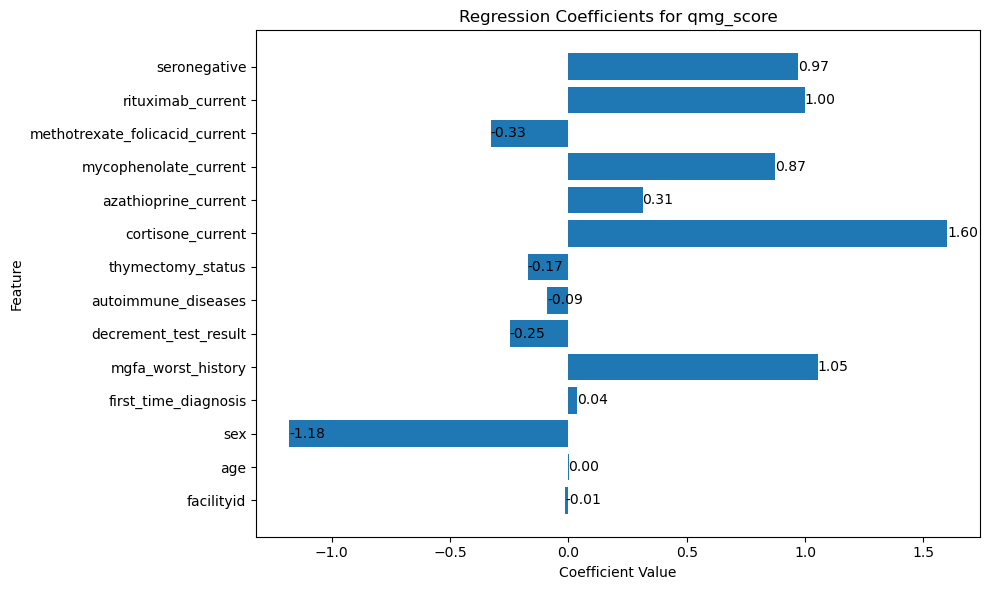

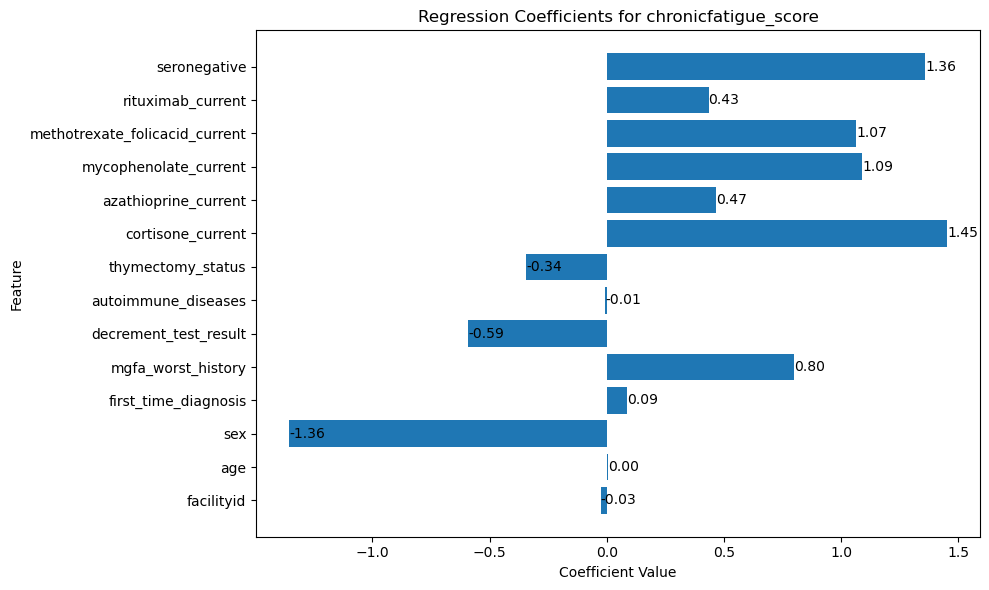

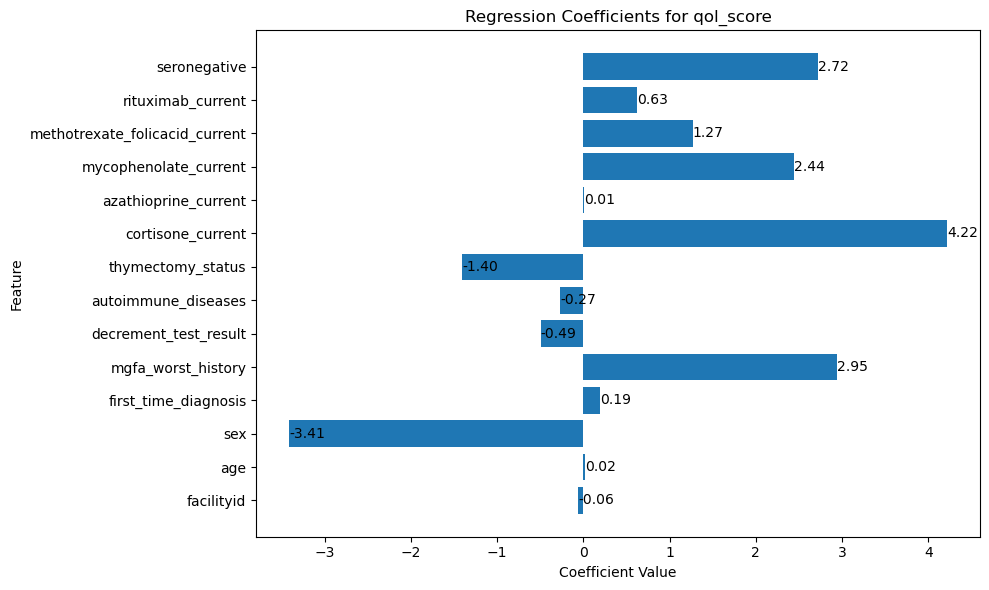

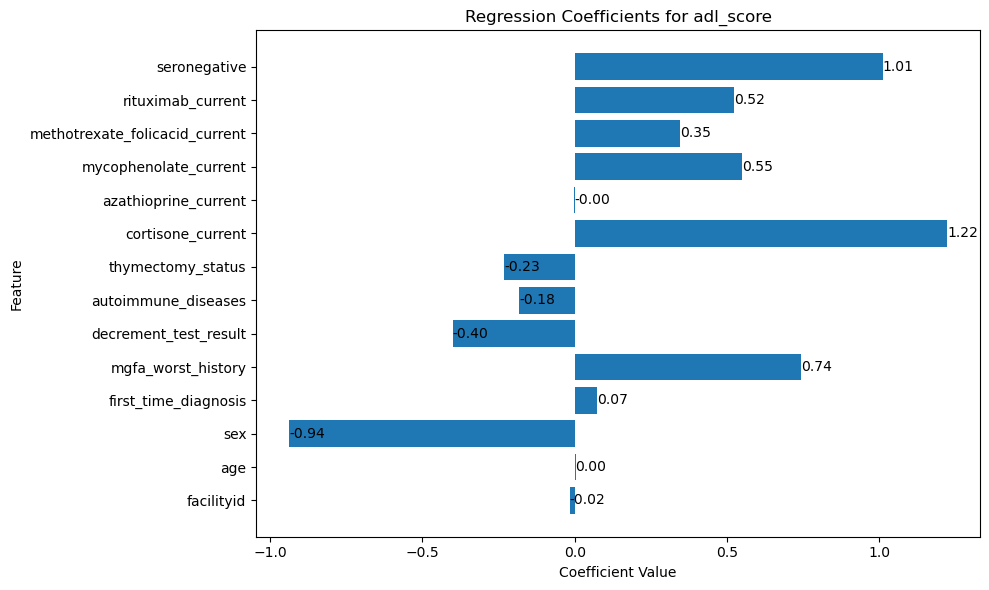

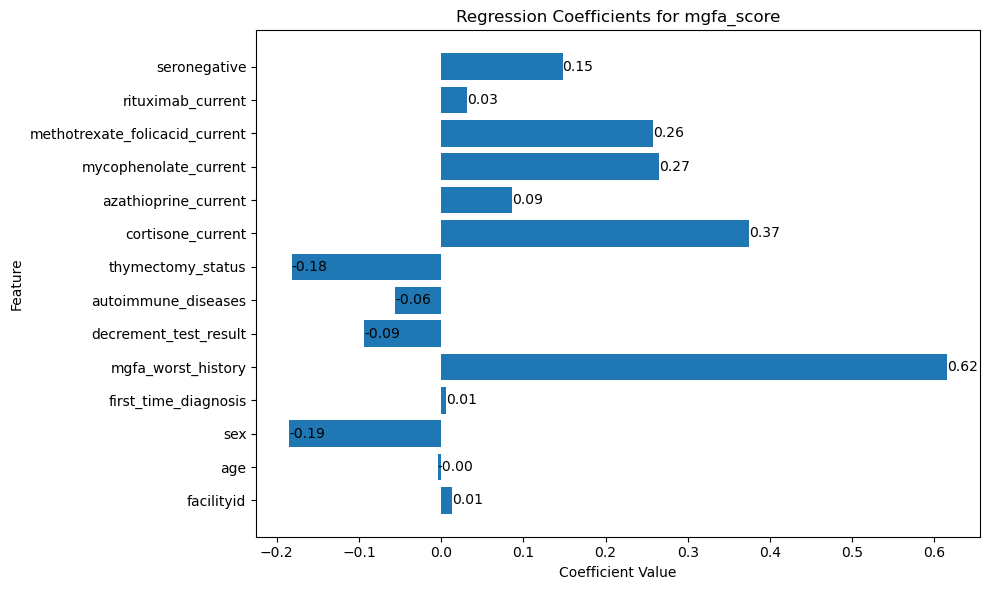

In [36]:
for target in targets:
    plt.figure(figsize=(10, 6))

    coef_series = coefficients_df[target]

    plt.barh(
        y=coef_series.index,
        width=coef_series.values
    )

    plt.title(f'Regression Coefficients for {target}')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')

    # Add coefficient labels
    for i, value in enumerate(coef_series.values):
        plt.text(value, i, f'{value:.2f}', va='center')

    plt.tight_layout()
    plt.show()


# Coefficients for both Original & Imputed Dataset

In [37]:
import scipy.stats as stats
import statsmodels.api as sm

In [38]:
features = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'seronegative'
]
targets = [
    'qmg_score',
    'chronicfatigue_score',
    'qol_score',
    'adl_score',
    'mgfa_score'
]

In [39]:
# X now contains the renamed feature columns
X = df_cleaned[features]

# Initialize an empty DataFrame to store coefficients
coefficients_df = pd.DataFrame()

# Loop over each target and fit a Linear Regression model
for target in targets:
    y = df_cleaned[target]
    model = LinearRegression()
    model.fit(X, y)
    
    # Store coefficients for this target
    target_coefficients = (
        pd.DataFrame(model.coef_, index=features, columns=[f'coefficient_{target}'])
        .round(4)
    )
    
    # Append to master table
    coefficients_df = pd.concat([coefficients_df, target_coefficients], axis=1)

# Output final table
coefficients_df

,coefficient_qmg_score,coefficient_chronicfatigue_score,coefficient_qol_score,coefficient_adl_score,coefficient_mgfa_score
facilityid,0.0628,-0.0434,0.0206,0.0226,0.0242
age,0.0022,-0.1031,-0.0619,-0.0058,0.0031
sex,-2.2670,-2.4000,-8.9655,-2.3493,-0.3204
first_time_diagnosis,-0.0827,0.0436,0.2041,-0.0163,0.0231
mgfa_worst_history,1.3773,0.9523,2.9861,0.7972,0.5977
decrement_test_result,0.6865,-1.7415,1.4040,-0.3547,0.2208
autoimmune_diseases,-0.5896,-0.7670,-7.1064,-1.6060,-0.3018
thymectomy_status,-1.1645,-2.0278,-1.5337,0.1011,-0.1992
cortisone_current,2.3757,0.8172,6.7613,1.7515,0.2578
azathioprine_current,1.9303,1.2439,1.8678,0.9337,0.2397


In [40]:
X = df_imputed_dataset[features]

# Initialize an empty DataFrame to store coefficients
coefficients_df = pd.DataFrame()

# Loop over each target and fit a Linear Regression model
for target in targets:
    y = df_imputed_dataset[target]
    model = LinearRegression()
    model.fit(X, y)
    
    # Create a DataFrame to store the coefficients for this target
    target_coefficients = pd.DataFrame(model.coef_, index=features, columns=[f'coefficient_{target}']).round(4)
    
    # Append the coefficients to the main DataFrame
    coefficients_df = pd.concat([coefficients_df, target_coefficients], axis=1)

# Output the final table of coefficients
coefficients_df

,coefficient_qmg_score,coefficient_chronicfatigue_score,coefficient_qol_score,coefficient_adl_score,coefficient_mgfa_score
facilityid,-0.0130,-0.0264,-0.0628,-0.0162,0.0132
age,0.0006,0.0044,0.0172,0.0026,-0.0042
sex,-1.1806,-1.3551,-3.4140,-0.9380,-0.1851
first_time_diagnosis,0.0352,0.0873,0.1912,0.0727,0.0064
mgfa_worst_history,1.0528,0.7989,2.9461,0.7423,0.6156
decrement_test_result,-0.2491,-0.5918,-0.4941,-0.4008,-0.0940
autoimmune_diseases,-0.0910,-0.0066,-0.2663,-0.1822,-0.0562
thymectomy_status,-0.1715,-0.3431,-1.4033,-0.2325,-0.1820
cortisone_current,1.6000,1.4522,4.2186,1.2223,0.3742
azathioprine_current,0.3131,0.4680,0.0098,-0.0021,0.0866


# Confidence Intervals for both Original & Imputed Dataset

In [41]:
# Initialize an empty DataFrame to store confidence intervals
ols_confidence_intervals_df = pd.DataFrame()

# Loop over each target and fit an OLS model
for target in targets:
    y = df_cleaned[target]
    
    # Add a constant term to the model (intercept)
    X_with_const = sm.add_constant(X)
    
    # Align indices between X and y by dropping rows where either is missing
    X_with_const, y_aligned = X_with_const.align(y, join='inner', axis=0)
    
    # Fit OLS model
    ols_model = sm.OLS(y_aligned, X_with_const).fit()
    
    # Get the confidence intervals
    confidence_intervals = ols_model.conf_int()
    
    # Rename the columns for clarity
    confidence_intervals.columns = [f'Lower_CI_{target}', f'Upper_CI_{target}']
    
    # Append the confidence intervals to the main DataFrame
    ols_confidence_intervals_df = pd.concat([ols_confidence_intervals_df, confidence_intervals], axis=1)

# Round the confidence intervals to 4 decimal places
ols_confidence_intervals_df = ols_confidence_intervals_df.round(4)

# Output the final table of OLS confidence intervals
ols_confidence_intervals_df

,Lower_CI_qmg_score,Upper_CI_qmg_score,Lower_CI_chronicfatigue_score,Upper_CI_chronicfatigue_score,Lower_CI_qol_score,Upper_CI_qol_score,Lower_CI_adl_score,Upper_CI_adl_score,Lower_CI_mgfa_score,Upper_CI_mgfa_score
const,-496303.1575,242902.1046,-402104.6169,577280.1743,-1.052113e+06,968842.2214,-308800.8041,217634.4115,-130723.6951,33061.8256
facilityid,-0.1203,0.2458,-0.2859,0.1992,-4.799000e-01,0.5211,-0.1078,0.1529,-0.0164,0.0647
age,-0.0602,0.0647,-0.1858,-0.0203,-2.327000e-01,0.1089,-0.0503,0.0387,-0.0107,0.0170
sex,-4.2053,-0.3287,-4.9681,0.1681,-1.426470e+01,-3.6663,-3.7296,-0.9689,-0.7498,0.1091
first_time_diagnosis,-0.3299,0.1645,-0.2839,0.3712,-4.718000e-01,0.8799,-0.1924,0.1597,-0.0317,0.0779
mgfa_worst_history,0.8071,1.9475,0.1968,1.7077,1.427200e+00,4.5449,0.3911,1.2033,0.4713,0.7240
decrement_test_result,-1.2354,2.6083,-4.2878,0.8048,-3.850300e+00,6.6582,-1.7234,1.0140,-0.2050,0.6467
autoimmune_diseases,-2.7623,1.5831,-3.6456,2.1116,-1.304640e+01,-1.1664,-3.1534,-0.0587,-0.7832,0.1796
thymectomy_status,-3.4643,1.1352,-5.0747,1.0192,-7.821100e+00,4.7538,-1.5367,1.7389,-0.7088,0.3103
cortisone_current,0.5339,4.2175,-1.6230,3.2575,1.725900e+00,11.7967,0.4399,3.0632,-0.1503,0.6658


In [42]:
# Initialize an empty DataFrame to store confidence intervals
ols_confidence_intervals_df = pd.DataFrame()

# Loop over each target and fit an OLS model
for target in targets:
    y = df_imputed_dataset[target]
    
    # Add a constant term to the model (intercept)
    X_with_const = sm.add_constant(X)
    
    # Align indices between X and y by dropping rows where either is missing
    X_with_const, y_aligned = X_with_const.align(y, join='inner', axis=0)
    
    # Fit OLS model
    ols_model = sm.OLS(y_aligned, X_with_const).fit()
    
    # Get the confidence intervals
    confidence_intervals = ols_model.conf_int()
    
    # Rename the columns for clarity
    confidence_intervals.columns = [f'Lower_CI_{target}', f'Upper_CI_{target}']
    
    # Append the confidence intervals to the main DataFrame
    ols_confidence_intervals_df = pd.concat([ols_confidence_intervals_df, confidence_intervals], axis=1)

# Round the confidence intervals to 4 decimal places
ols_confidence_intervals_df = ols_confidence_intervals_df.round(4)

# Output the final table of OLS confidence intervals
ols_confidence_intervals_df

,Lower_CI_qmg_score,Upper_CI_qmg_score,Lower_CI_chronicfatigue_score,Upper_CI_chronicfatigue_score,Lower_CI_qol_score,Upper_CI_qol_score,Lower_CI_adl_score,Upper_CI_adl_score,Lower_CI_mgfa_score,Upper_CI_mgfa_score
const,-45426.6727,98095.9876,-48840.8031,155654.6612,-76773.1792,330482.8353,-18166.0675,83720.9938,-45662.4041,-7765.4255
facilityid,-0.0486,0.0225,-0.0771,0.0242,-0.1637,0.0380,-0.0415,0.0090,0.0038,0.0226
age,-0.0108,0.0120,-0.0118,0.0206,-0.0151,0.0494,-0.0054,0.0107,-0.0072,-0.0012
sex,-1.5757,-0.7856,-1.9180,-0.7923,-4.5350,-2.2930,-1.2184,-0.6575,-0.2894,-0.0808
first_time_diagnosis,-0.0135,0.0839,0.0179,0.1566,0.0530,0.3293,0.0381,0.1072,-0.0064,0.0193
mgfa_worst_history,0.9424,1.1632,0.6417,0.9562,2.6329,3.2594,0.6639,0.8207,0.5865,0.6448
decrement_test_result,-0.6201,0.1220,-1.1206,-0.0631,-1.5471,0.5589,-0.6642,-0.1374,-0.1919,0.0040
autoimmune_diseases,-0.5165,0.3346,-0.6129,0.5998,-1.4738,0.9412,-0.4843,0.1199,-0.1685,0.0562
thymectomy_status,-0.5904,0.2473,-0.9399,0.2537,-2.5918,-0.2147,-0.5299,0.0648,-0.2926,-0.0714
cortisone_current,1.2373,1.9627,0.9354,1.9690,3.1894,5.2478,0.9648,1.4798,0.2785,0.4700


# scoreqmg_neu

In [43]:
columns_scoreqmg = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'qmg_score',
    'seronegative'
]

df_scoreqmg_neu = df_original[columns_scoreqmg]
df_scoreqmg = df_scoreqmg_neu.dropna()
df_scoreqmg.isnull().sum()

facilityid                        0
age                               0
sex                               0
first_time_diagnosis              0
mgfa_worst_history                0
decrement_test_result             0
autoimmune_diseases               0
thymectomy_status                 0
cortisone_current                 0
azathioprine_current              0
mycophenolate_current             0
methotrexate_folicacid_current    0
rituximab_current                 0
qmg_score                         0
seronegative                      0
dtype: int64

# chronicfatigue_neu

In [44]:
columns_chronicfatigue = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'chronicfatigue_score',
    'seronegative'
]
df_chronicfatigue_neu = df_original[columns_chronicfatigue]
df_chronicfatigue = df_chronicfatigue_neu.dropna()
df_chronicfatigue.isnull().sum()

facilityid                        0
age                               0
sex                               0
first_time_diagnosis              0
mgfa_worst_history                0
decrement_test_result             0
autoimmune_diseases               0
thymectomy_status                 0
cortisone_current                 0
azathioprine_current              0
mycophenolate_current             0
methotrexate_folicacid_current    0
rituximab_current                 0
chronicfatigue_score              0
seronegative                      0
dtype: int64

# scoreqol_neu

In [45]:
columns_scoreqol_neu = [
    'facilityid', 'age', 'sex', 'first_time_diagnosis', 'mgfa_worst_history',
    'decrement_test_result', 'autoimmune_diseases', 'thymectomy_status',
    'cortisone_current', 'azathioprine_current', 'mycophenolate_current',
    'methotrexate_folicacid_current', 'rituximab_current',
    'qol_score', 'seronegative'
]
df_scoreqol_neu = df_original[columns_scoreqol_neu]
df_scoreqol = df_scoreqol_neu.dropna()
df_scoreqol.isnull().sum()

facilityid                        0
age                               0
sex                               0
first_time_diagnosis              0
mgfa_worst_history                0
decrement_test_result             0
autoimmune_diseases               0
thymectomy_status                 0
cortisone_current                 0
azathioprine_current              0
mycophenolate_current             0
methotrexate_folicacid_current    0
rituximab_current                 0
qol_score                         0
seronegative                      0
dtype: int64

# scoreadl_neu

In [46]:
columns_scoreadl = [
    'facilityid',
    'age',
    'sex',
    'first_time_diagnosis',
    'mgfa_worst_history',
    'decrement_test_result',
    'autoimmune_diseases',
    'thymectomy_status',
    'cortisone_current',
    'azathioprine_current',
    'mycophenolate_current',
    'methotrexate_folicacid_current',
    'rituximab_current',
    'adl_score',
    'seronegative'
]

df_scoreadl_neu = df_original[columns_scoreadl]
df_scoreadl = df_scoreadl_neu.dropna()
df_scoreadl.isnull().sum()

facilityid                        0
age                               0
sex                               0
first_time_diagnosis              0
mgfa_worst_history                0
decrement_test_result             0
autoimmune_diseases               0
thymectomy_status                 0
cortisone_current                 0
azathioprine_current              0
mycophenolate_current             0
methotrexate_folicacid_current    0
rituximab_current                 0
adl_score                         0
seronegative                      0
dtype: int64

# aktueller_mgfa_score

In [47]:
columns_mgfa_score = [
    'facilityid', 'age', 'sex', 'first_time_diagnosis', 'mgfa_worst_history',
    'decrement_test_result', 'autoimmune_diseases', 'thymectomy_status',
    'cortisone_current', 'azathioprine_current', 'mycophenolate_current',
    'methotrexate_folicacid_current', 'rituximab_current', 'mgfa_score',
    'seronegative'
]

df_mgfa_score = df_original[columns_mgfa_score]
df_mgfa = df_mgfa_score.dropna()
df_mgfa.isnull().sum()

facilityid                        0
age                               0
sex                               0
first_time_diagnosis              0
mgfa_worst_history                0
decrement_test_result             0
autoimmune_diseases               0
thymectomy_status                 0
cortisone_current                 0
azathioprine_current              0
mycophenolate_current             0
methotrexate_folicacid_current    0
rituximab_current                 0
mgfa_score                        0
seronegative                      0
dtype: int64

# Forest Plot for Original & Imputed Dataset for Seronegative

In [48]:
# Function to perform regression and return the coefficient and confidence interval for seronegative
def get_seronegative_results(df, features, target):
    X = df[features]
    y = df[target]
    
    # Add constant for intercept
    X = sm.add_constant(X)
    
    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    
    # Get the coefficient and confidence interval for 'seronegative'
    seronegative_coef = round(model.params['seronegative'], 2)
    seronegative_conf = model.conf_int().loc['seronegative'].round(2)  
    
    return seronegative_coef, seronegative_conf

# Function to plot the forest plot with regression coefficients and 95% CI in an extra column
def plot_forest_plot_with_coef_ci(coefs, confs, targets, datasets, title, show_row_count=False):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Add labels and ticks with the number of rows for each dataset (only for original dataset if show_row_count is True)
    if show_row_count:
        targets_with_row_count = [f'{target} (n={datasets[target].shape[0]})' for target in targets]
    else:
        targets_with_row_count = targets

    # Plot the regression coefficients and confidence intervals
    for i, (coef, (lower, upper)) in enumerate(zip(coefs, confs)):
        ax.errorbar(coef, i, xerr=[[coef - lower], [upper - coef]], fmt='s', color='black', ecolor='gray', elinewidth=2, capsize=3)

    # Add vertical line at 0
    ax.axvline(x=0, linestyle='--', color='black', linewidth=1)

    # Add the targets with row counts or not based on the `show_row_count` flag
    ax.set_yticks(range(len(coefs)))
    ax.set_yticklabels(targets_with_row_count)
    ax.set_xlim([-1, 7])

    ax.set_xlabel('Coefficient')
    ax.set_title(title)
    
    # Add the regression coefficient and 95% CI numbers in an extra column (outside the plot)
    for i, (coef, (lower, upper)) in enumerate(zip(coefs, confs)):
        ax.text(7.2, i, f'{coef:.2f}', va='center', ha='left', fontsize=10)
        ax.text(8.5, i, f'[{lower:.2f}, {upper:.2f}]', va='center', ha='left', fontsize=10, color='green')

        ax.text(7.2, len(coefs) + 0.5, 'Coefficient', va='center', ha='left', fontsize=12, fontweight='bold')
        ax.text(9.0, len(coefs) + 0.5, '95% CI', va='center', ha='left', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Features (renamed)
features = [
    'facilityid', 'age', 'sex', 'first_time_diagnosis', 'mgfa_worst_history', 
    'decrement_test_result', 'autoimmune_diseases', 'thymectomy_status', 
    'cortisone_current', 'azathioprine_current', 'mycophenolate_current', 
    'methotrexate_folicacid_current', 'rituximab_current', 'seronegative'
]

# Target datasets (original, using renamed target column names)
original_datasets = {
    'qmg_score': df_scoreqmg,
    'chronicfatigue_score': df_chronicfatigue,
    'qol_score': df_scoreqol,
    'adl_score': df_scoreadl,
    'mgfa_score': df_mgfa
}

# Imputed dataset
df_imputed_dataset = df_imputed_dataset

# Lists to store coefficients and confidence intervals for imputed datasets
coefs_imputed = []
confs_imputed = []

# Lists to store coefficients and confidence intervals for original datasets
coefs_original = []
confs_original = []


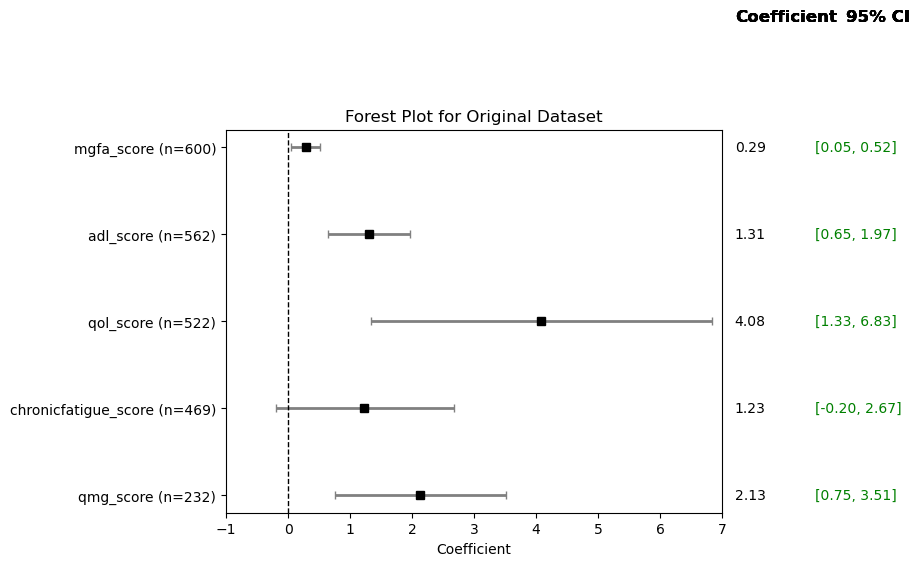

In [49]:
# Get results for each target in the original dataset
for target, df in original_datasets.items():
    coef, conf = get_seronegative_results(df, features, target)
    coefs_original.append(coef)
    confs_original.append(conf)

# Convert to NumPy arrays for easier manipulation
confs_original = np.array(confs_original)

# Plot for the original dataset WITH row counts and regression coefficient, 95% CI in an extra column
plot_forest_plot_with_coef_ci(
    coefs_original,
    confs_original,
    list(original_datasets.keys()),
    original_datasets,
    'Forest Plot for Original Dataset',
    show_row_count=True
)

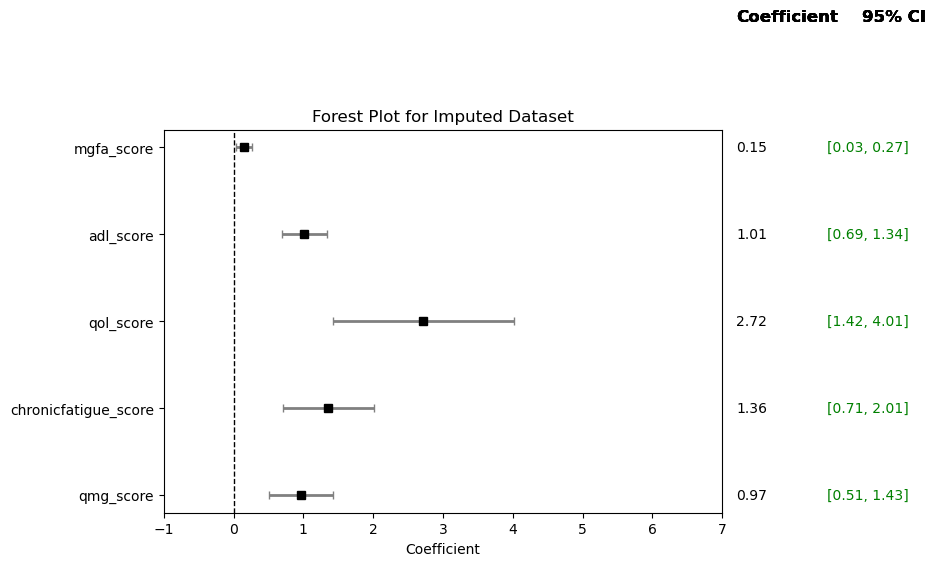

In [50]:
# Get results for each target in the imputed dataset
for target in original_datasets.keys():
    coef, conf = get_seronegative_results(df_imputed_dataset, features, target)
    coefs_imputed.append(coef)
    confs_imputed.append(conf)

# Convert to NumPy arrays for easier manipulation
confs_imputed = np.array(confs_imputed)

# Plot for the imputed dataset WITHOUT row counts
plot_forest_plot_with_coef_ci(
    coefs_imputed,
    confs_imputed,
    list(original_datasets.keys()),
    original_datasets,
    'Forest Plot for Imputed Dataset',
    show_row_count=False
)

# Forest Plot for Original & Imputed Dataset for Sex

/var/folders/x0/0d0s17_j0ngcgcjy71h5nc4m0000gn/T/ipykernel_89010/3041721054.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


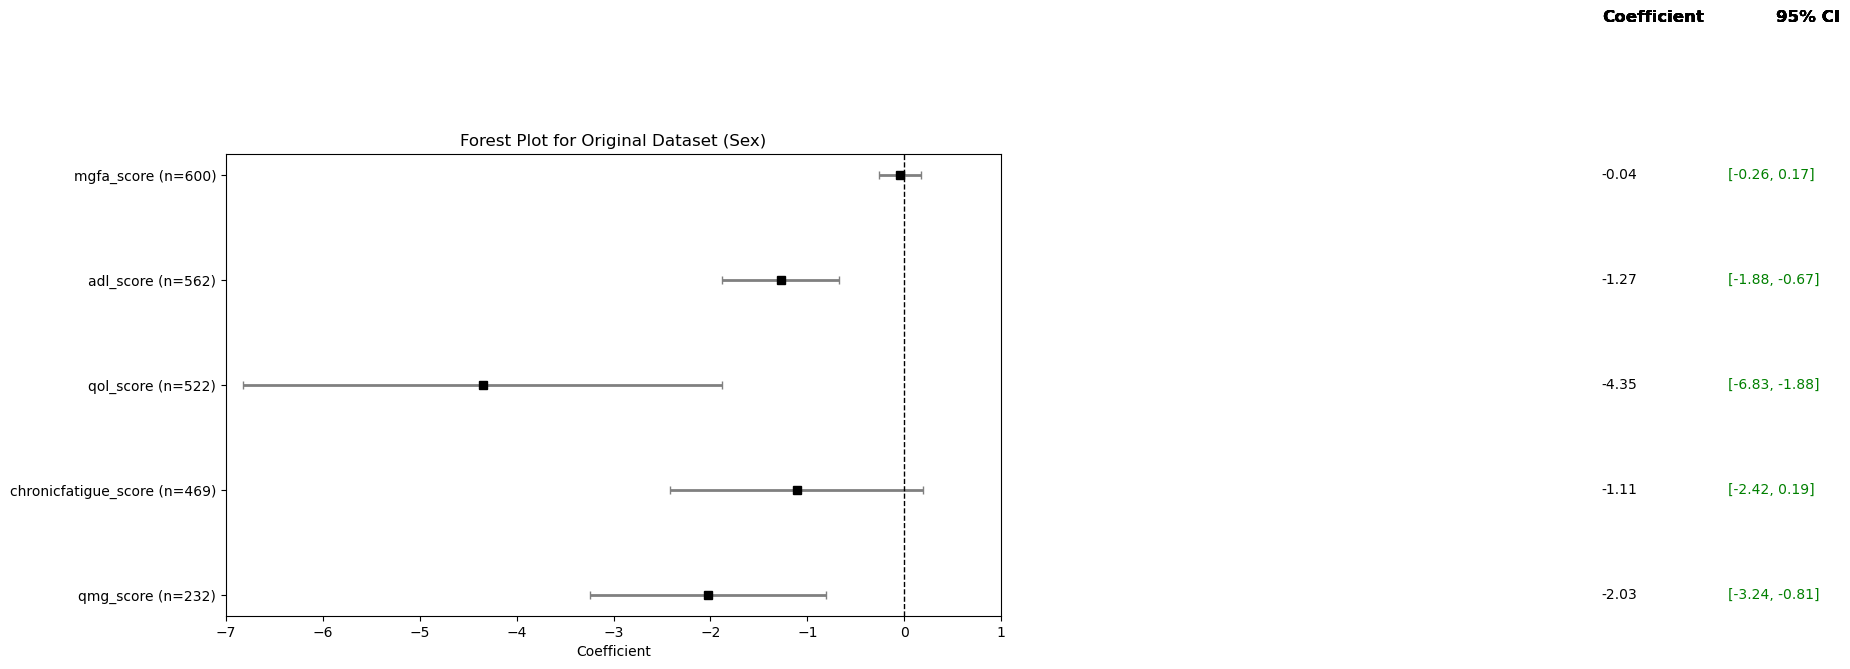

/var/folders/x0/0d0s17_j0ngcgcjy71h5nc4m0000gn/T/ipykernel_89010/3041721054.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


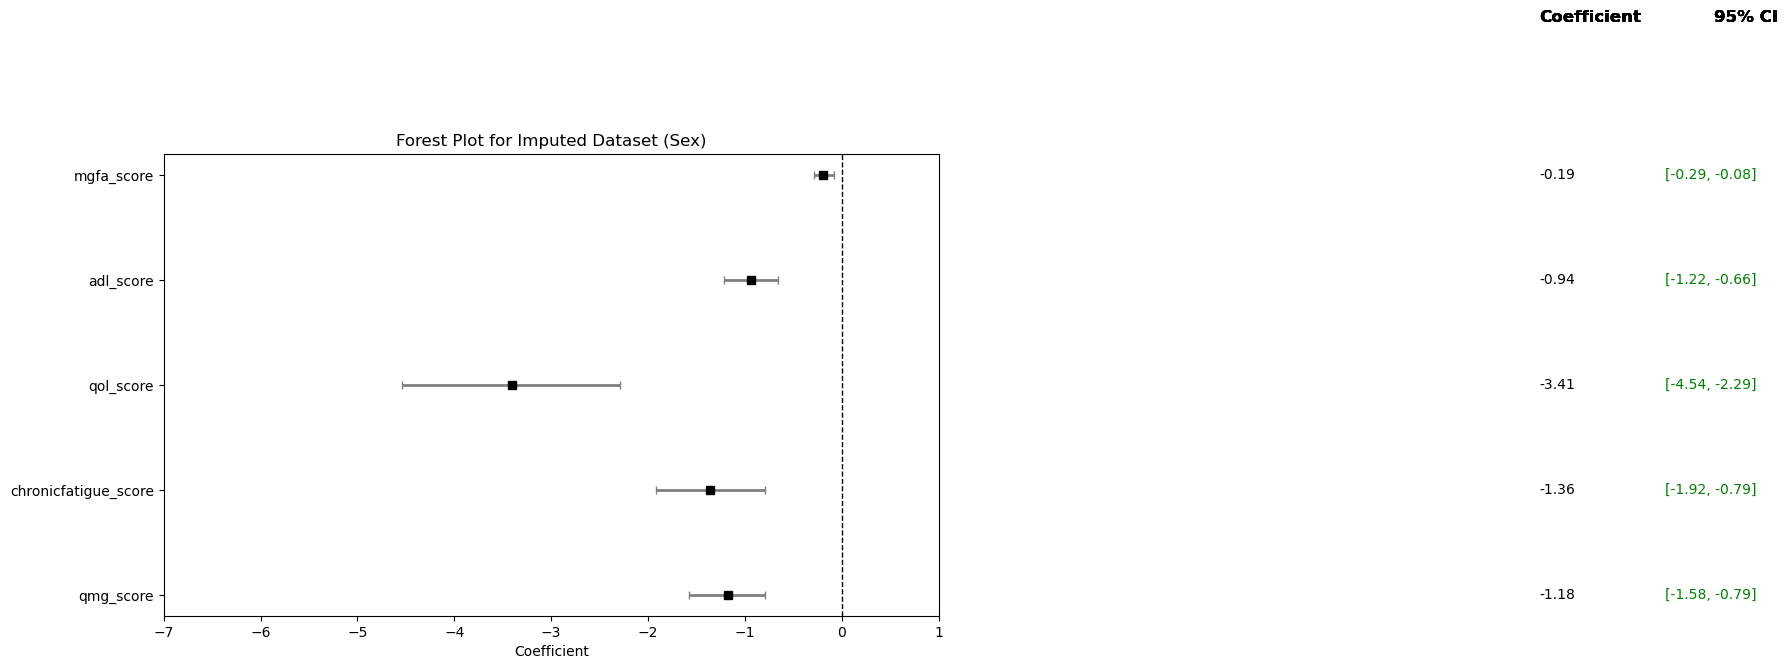

In [51]:
# Function to perform regression and return the coefficient and confidence interval for 'sex'
def get_sex_results(df, features, target):
    X = df[features]
    y = df[target]
    
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    sex_coef = round(model.params['sex'], 2)
    sex_conf = model.conf_int().loc['sex'].round(2)  
    
    return sex_coef, sex_conf

# Function to plot forest plot
def plot_forest_plot_with_coef_ci(coefs, confs, targets, datasets, title, show_row_count=False):
    fig, ax = plt.subplots(figsize=(10, 6))

    if show_row_count:
        targets_with_row_count = [f'{target} (n={datasets[target].shape[0]})' for target in targets]
    else:
        targets_with_row_count = targets

    for i, (coef, (lower, upper)) in enumerate(zip(coefs, confs)):
        ax.errorbar(coef, i, xerr=[[coef - lower], [upper - coef]],
                    fmt='s', color='black', ecolor='gray', elinewidth=2, capsize=3)

    ax.axvline(x=0, linestyle='--', color='black', linewidth=1)
    ax.set_yticks(range(len(coefs)))
    ax.set_yticklabels(targets_with_row_count)
    ax.set_xlim([-7, 1])

    ax.set_xlabel('Coefficient')
    ax.set_title(title)

    for i, (coef, (lower, upper)) in enumerate(zip(coefs, confs)):
        ax.text(7.2, i, f'{coef:.2f}', va='center', ha='left', fontsize=10)
        ax.text(8.5, i, f'[{lower:.2f}, {upper:.2f}]', va='center', ha='left',
                fontsize=10, color='green')

        ax.text(7.2, len(coefs) + 0.5, 'Coefficient', va='center', ha='left',
                fontsize=12, fontweight='bold')
        ax.text(9.0, len(coefs) + 0.5, '95% CI', va='center', ha='left',
                fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Updated features
features = [
    'facilityid', 'age', 'sex', 'first_time_diagnosis', 'mgfa_worst_history',
    'decrement_test_result', 'autoimmune_diseases', 'thymectomy_status',
    'cortisone_current', 'azathioprine_current', 'mycophenolate_current',
    'methotrexate_folicacid_current', 'rituximab_current', 'seronegative'
]

# Updated target datasets
original_datasets = {
    'qmg_score': df_scoreqmg,
    'chronicfatigue_score': df_chronicfatigue,
    'qol_score': df_scoreqol,
    'adl_score': df_scoreadl,
    'mgfa_score': df_mgfa
}

df_imputed_dataset = df_imputed_dataset

coefs_imputed = []
confs_imputed = []
coefs_original = []
confs_original = []

# Original dataset results
for target, df in original_datasets.items():
    coef, conf = get_sex_results(df, features, target)
    coefs_original.append(coef)
    confs_original.append(conf)

confs_original = np.array(confs_original)

plot_forest_plot_with_coef_ci(
    coefs_original, confs_original,
    list(original_datasets.keys()),
    original_datasets,
    'Forest Plot for Original Dataset (Sex)',
    show_row_count=True
)

# Imputed dataset results
for target in original_datasets.keys():
    coef, conf = get_sex_results(df_imputed_dataset, features, target)
    coefs_imputed.append(coef)
    confs_imputed.append(conf)

confs_imputed = np.array(confs_imputed)

plot_forest_plot_with_coef_ci(
    coefs_imputed, confs_imputed,
    list(original_datasets.keys()),
    original_datasets,
    'Forest Plot for Imputed Dataset (Sex)',
    show_row_count=False
)